<a href="https://colab.research.google.com/github/SSILY/SSILY.github.io/blob/main/Proyecto_integracion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importar las librerias

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# 2. Leemos el dataset para colocarlo en un dataframe de pandas

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/Obfuscated-MalMem2022.csv')

# 3. Queremos saber el tamaño del dataframe

In [ ]:
df.shape

(58596, 57)

# 4. Para saber las columnas (caracteristicas) del dataframe

In [ ]:
df.dtypes

Category                                   object
pslist.nproc                                int64
pslist.nppid                                int64
pslist.avg_threads                        float64
pslist.nprocs64bit                          int64
pslist.avg_handlers                       float64
dlllist.ndlls                               int64
dlllist.avg_dlls_per_proc                 float64
handles.nhandles                            int64
handles.avg_handles_per_proc              float64
handles.nport                               int64
handles.nfile                               int64
handles.nevent                              int64
handles.ndesktop                            int64
handles.nkey                                int64
handles.nthread                             int64
handles.ndirectory                          int64
handles.nsemaphore                          int64
handles.ntimer                              int64
handles.nsection                            int64


# 5. Queremos saber el contenido del dataframe

In [ ]:
df.describe()

,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,...,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric
count,58596.000000,58596.000000,58596.000000,58596.0,58596.000000,58596.000000,58596.000000,5.859600e+04,58596.000000,58596.0,...,58596.000000,58596.000000,58596.000000,58596.000000,58596.000000,58596.0,58596.000000,58596.000000,58596.000000,58596.000000
mean,41.394771,14.713837,11.341655,0.0,247.509819,1810.805447,43.707806,1.025858e+04,249.560958,0.0,...,391.347549,221.406581,25.996245,25.063417,116.879514,0.0,121.995546,86.905659,0.000853,7.999881
std,5.777249,2.656748,1.588231,0.0,111.857790,329.782639,5.742023,4.866864e+03,145.999866,0.0,...,4.529704,1.991087,0.170790,1.529628,1.550401,0.0,2.822858,3.134117,0.029199,0.010929
min,21.000000,8.000000,1.650000,0.0,34.962500,670.000000,7.333333,3.514000e+03,71.139241,0.0,...,94.000000,55.000000,6.000000,7.000000,26.000000,0.0,30.000000,50.000000,0.000000,7.000000
25%,40.000000,12.000000,9.972973,0.0,208.725000,1556.000000,38.833333,8.393000e+03,209.648228,0.0,...,389.000000,221.000000,26.000000,24.000000,116.000000,0.0,121.000000,87.000000,0.000000,8.000000
50%,41.000000,15.000000,11.000000,0.0,243.963710,1735.000000,42.781524,9.287500e+03,247.208951,0.0,...,389.000000,221.000000,26.000000,24.000000,116.000000,0.0,122.000000,87.000000,0.000000,8.000000
75%,43.000000,16.000000,12.861955,0.0,289.974322,2087.000000,49.605280,1.219300e+04,291.355050,0.0,...,395.000000,222.000000,26.000000,27.000000,118.000000,0.0,123.000000,88.000000,0.000000,8.000000
max,240.000000,72.000000,16.818182,0.0,24845.951220,3443.000000,53.170732,1.047310e+06,33784.193550,0.0,...,395.000000,222.000000,26.000000,27.000000,118.000000,0.0,129.000000,89.000000,1.000000,8.000000


# 6. Función para contar las ocurrencias de una columna y almacenarla en un diccionario

In [4]:
def contar_ocurrencias(df, columna):
    return df[columna].apply(lambda x: 1 if x > 0 else 0).sum()

def contar_ocurrencias_columnas(df, columnas):
    resultados = {}
    for columna in columnas:
        if columna != 'Category' and columna != 'Class':  # Excluir la primera y la última columna
            resultado = contar_ocurrencias(df, columna)
            resultados[columna] = resultado
    return resultados

# Lista de nombres de columnas
columnas = df.columns.tolist()

# Generar el diccionario de resultados
resultados = contar_ocurrencias_columnas(df, columnas)

# Imprimir el diccionario de resultados
print(resultados)

{'pslist.nproc': 58596, 'pslist.nppid': 58596, 'pslist.avg_threads': 58596, 'pslist.nprocs64bit': 0, 'pslist.avg_handlers': 58596, 'dlllist.ndlls': 58596, 'dlllist.avg_dlls_per_proc': 58596, 'handles.nhandles': 58596, 'handles.avg_handles_per_proc': 58596, 'handles.nport': 0, 'handles.nfile': 58596, 'handles.nevent': 58596, 'handles.ndesktop': 58596, 'handles.nkey': 58596, 'handles.nthread': 58596, 'handles.ndirectory': 58596, 'handles.nsemaphore': 58596, 'handles.ntimer': 58596, 'handles.nsection': 58596, 'handles.nmutant': 58596, 'ldrmodules.not_in_load': 58596, 'ldrmodules.not_in_init': 58596, 'ldrmodules.not_in_mem': 58596, 'ldrmodules.not_in_load_avg': 58596, 'ldrmodules.not_in_init_avg': 58596, 'ldrmodules.not_in_mem_avg': 58596, 'malfind.ninjections': 58596, 'malfind.commitCharge': 58596, 'malfind.protection': 58596, 'malfind.uniqueInjections': 58596, 'psxview.not_in_pslist': 29502, 'psxview.not_in_eprocess_pool': 122, 'psxview.not_in_ethread_pool': 32958, 'psxview.not_in_pspcid

# 7. Ahora queremos un histograma con los resultados del conteo realizado por la función anterior

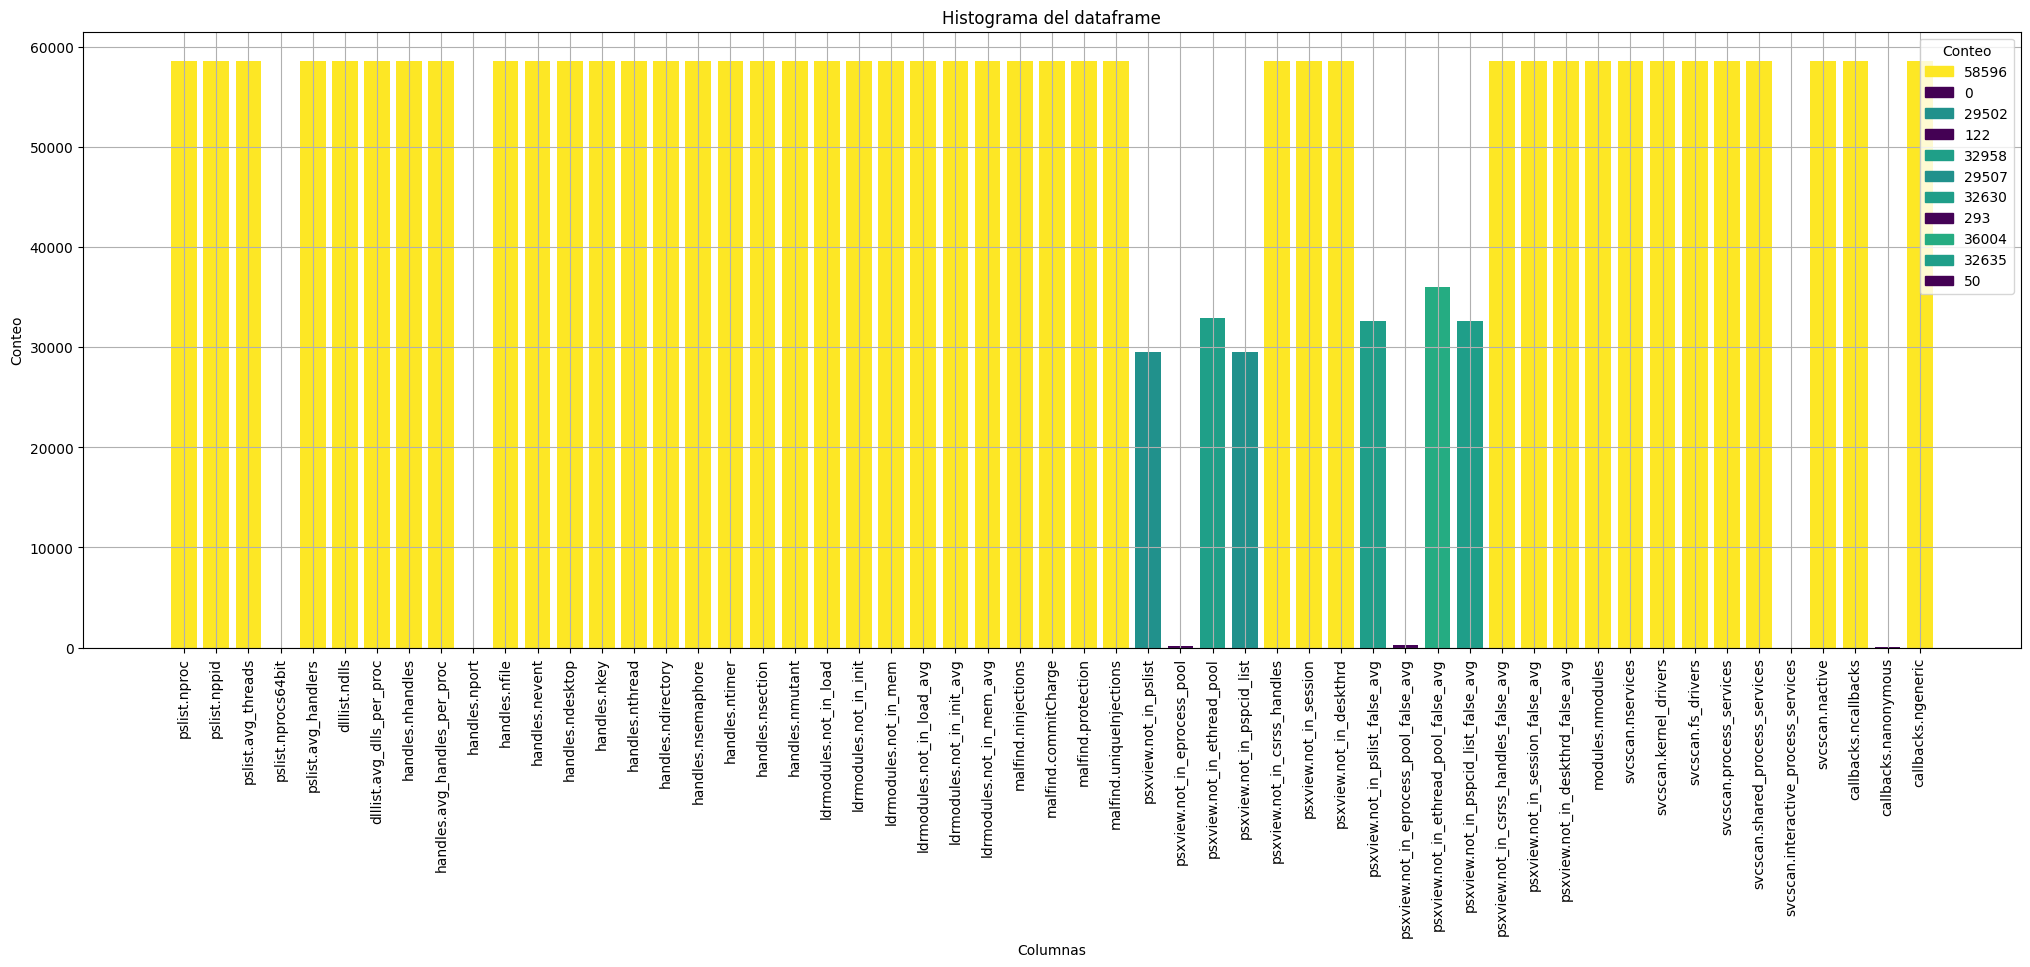

In [5]:
# Extraer las llaves y los valores del diccionario
columnas = list(resultados.keys())
conteos_valores = list(resultados.values())

# Crear el histograma con colores diferentes y leyendas numéricas con los valores de los conteos
plt.figure(figsize=(25, 8))
legend_labels = {}
for columna, conteo in zip(columnas, conteos_valores):
    if conteo not in legend_labels:
        plt.bar(columna, conteo, color=plt.cm.viridis(conteo / max(conteos_valores)), label=str(conteo))
        legend_labels[conteo] = columna
    else:
        plt.bar(columna, conteo, color=plt.cm.viridis(conteo / max(conteos_valores)))

plt.xlabel('Columnas')
plt.ylabel('Conteo')
plt.title('Histograma del dataframe')
plt.xticks(rotation=90)
legend_handles = [plt.Rectangle((0,0),1,1, color=plt.cm.viridis(cont / max(conteos_valores))) for cont in legend_labels]
plt.legend(legend_handles, legend_labels.keys(), title='Conteo', loc='best')
plt.grid(True)
plt.show()

# 8. Ahora tenemos que limpiar los datos, necesitamos quitar las caracteristicas con pocos o nulos datos.

In [6]:
# Encontrar las columnas que no tienen el valor 58596
columnas_a_limpiar = [columna for columna, conteo in resultados.items() if conteo != 58596]

# Mostrar las columnas que no cumplen el criterio
print("Columnas que no cumplen el criterio:")
print(columnas_a_limpiar)



Columnas que no cumplen el criterio:
['pslist.nprocs64bit', 'handles.nport', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.not_in_ethread_pool_false_avg', 'psxview.not_in_pspcid_list_false_avg', 'svcscan.interactive_process_services', 'callbacks.nanonymous']


## 8.1 Ahora que sabemos que columnas quitar, las quitamos del dataframe, con esto los datos están "limpios"

In [7]:
# Eliminar las columnas del DataFrame
df_limpio = df.drop(columns = columnas_a_limpiar)

## 8.2 Verificamos el nuevo dataframe

In [ ]:
df_limpio.shape

(58596, 45)

## 8.3 Una última verificación

{'pslist.nproc': 58596, 'pslist.nppid': 58596, 'pslist.avg_threads': 58596, 'pslist.avg_handlers': 58596, 'dlllist.ndlls': 58596, 'dlllist.avg_dlls_per_proc': 58596, 'handles.nhandles': 58596, 'handles.avg_handles_per_proc': 58596, 'handles.nfile': 58596, 'handles.nevent': 58596, 'handles.ndesktop': 58596, 'handles.nkey': 58596, 'handles.nthread': 58596, 'handles.ndirectory': 58596, 'handles.nsemaphore': 58596, 'handles.ntimer': 58596, 'handles.nsection': 58596, 'handles.nmutant': 58596, 'ldrmodules.not_in_load': 58596, 'ldrmodules.not_in_init': 58596, 'ldrmodules.not_in_mem': 58596, 'ldrmodules.not_in_load_avg': 58596, 'ldrmodules.not_in_init_avg': 58596, 'ldrmodules.not_in_mem_avg': 58596, 'malfind.ninjections': 58596, 'malfind.commitCharge': 58596, 'malfind.protection': 58596, 'malfind.uniqueInjections': 58596, 'psxview.not_in_csrss_handles': 58596, 'psxview.not_in_session': 58596, 'psxview.not_in_deskthrd': 58596, 'psxview.not_in_csrss_handles_false_avg': 58596, 'psxview.not_in_ses

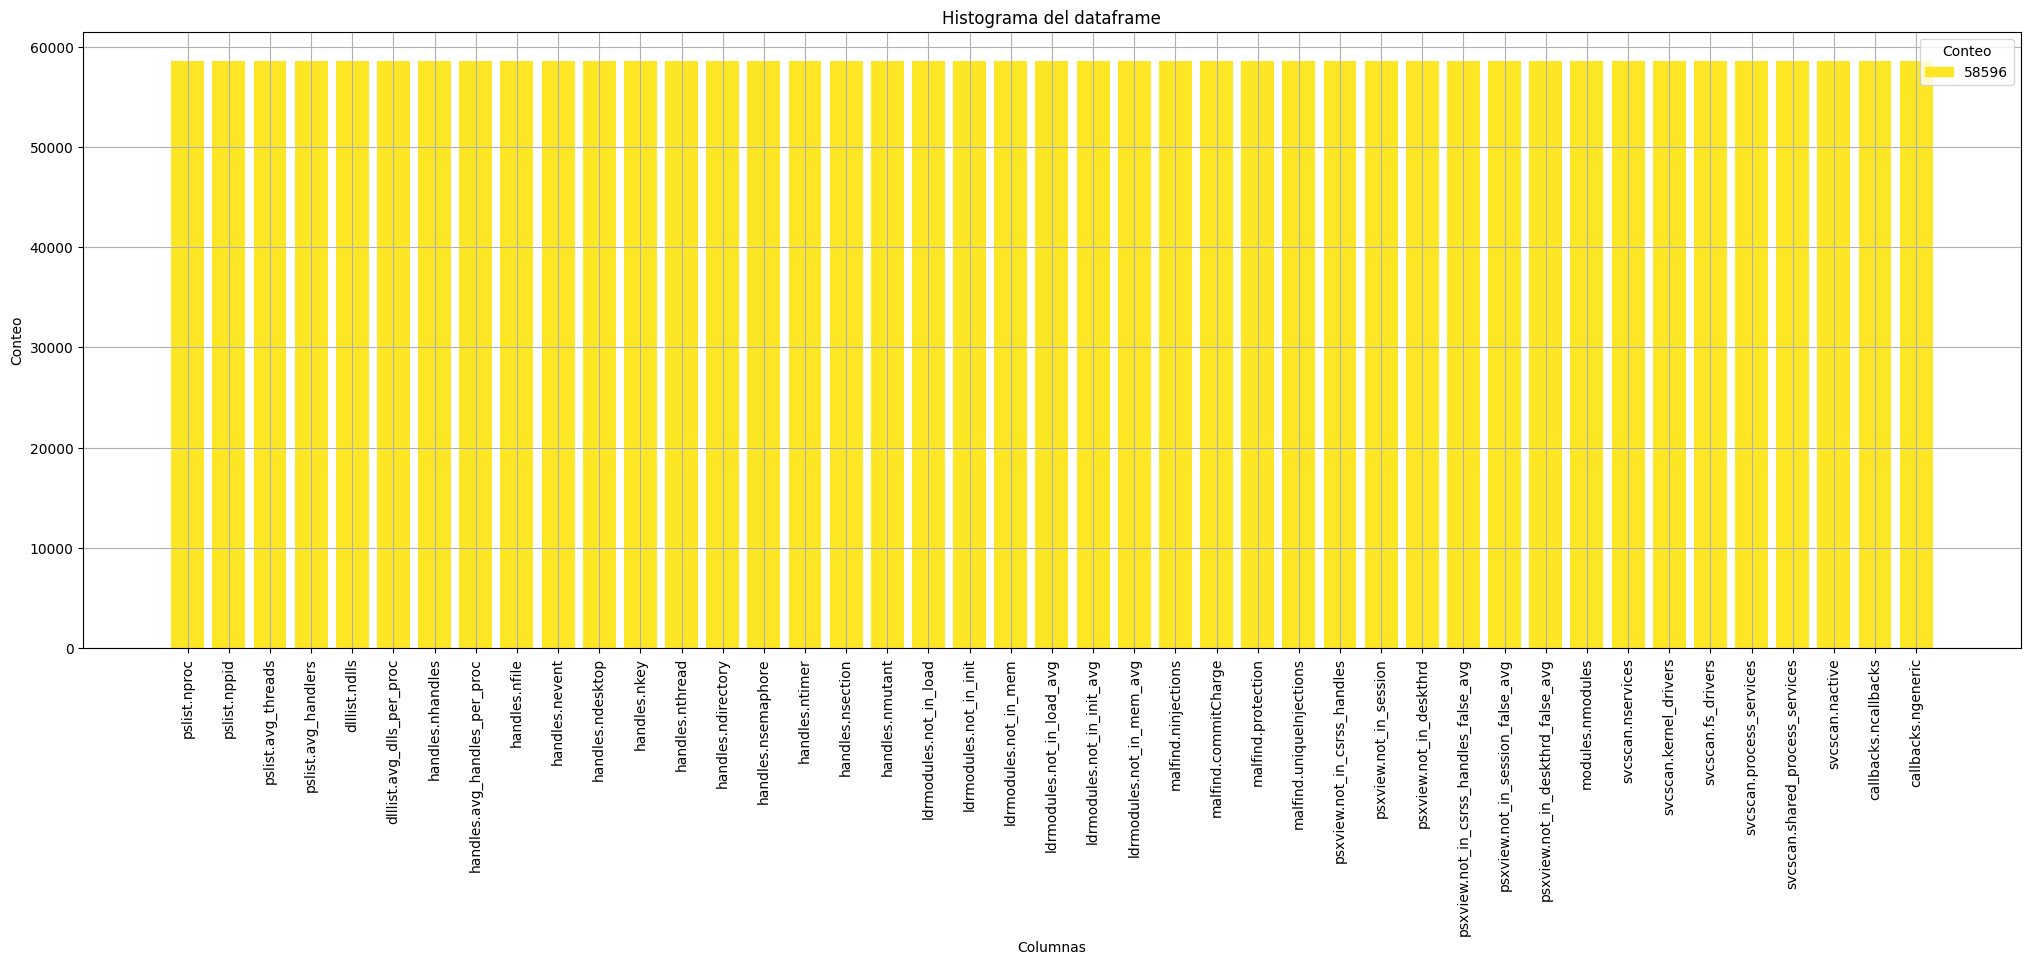

In [ ]:
# Lista de nombres de columnas
columnas = df_limpio.columns.tolist()

# Generar el diccionario de resultados
resultados = contar_ocurrencias_columnas(df_limpio, columnas)

# Imprimir el diccionario de resultados
print(resultados)

# Extraer las llaves y los valores del diccionario
columnas = list(resultados.keys())
conteos_valores = list(resultados.values())

# Crear el histograma con colores diferentes y leyendas numéricas con los valores de los conteos
plt.figure(figsize=(25, 8))
legend_labels = {}
for columna, conteo in zip(columnas, conteos_valores):
    if conteo not in legend_labels:
        plt.bar(columna, conteo, color=plt.cm.viridis(conteo / max(conteos_valores)), label=str(conteo))
        legend_labels[conteo] = columna
    else:
        plt.bar(columna, conteo, color=plt.cm.viridis(conteo / max(conteos_valores)))

plt.xlabel('Columnas')
plt.ylabel('Conteo')
plt.title('Histograma del dataframe')
plt.xticks(rotation=90)
legend_handles = [plt.Rectangle((0,0),1,1, color=plt.cm.viridis(cont / max(conteos_valores))) for cont in legend_labels]
plt.legend(legend_handles, legend_labels.keys(), title='Conteo', loc='best')
plt.grid(True)
plt.show()

# 9. Ahora queremos saber cuántos paquetes son Benignos y cuántos son Malware

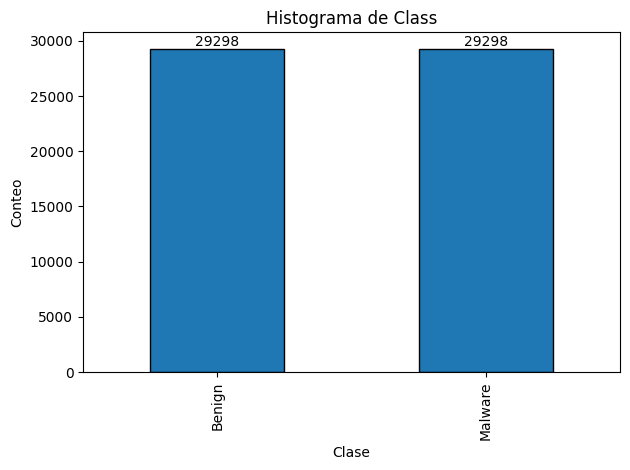

In [8]:
# Histograma de 'Class'

# Obtener los conteos de cada clase
contadores_clase = df['Class'].value_counts()

# Crear el histograma de Class
contadores_clase.plot(kind='bar', edgecolor='black')

# Añadir anotaciones con los valores de cada barra
for i, cont in enumerate(contadores_clase):
    plt.text(i, cont + 0.1, str(cont), ha='center', va='bottom')

# Configurar título y etiquetas
plt.title('Histograma de Class')
plt.xlabel('Clase')
plt.ylabel('Conteo')

plt.tight_layout()
plt.show()

# 10. Ahora queremos saber el conteo de cada tipo de Malware

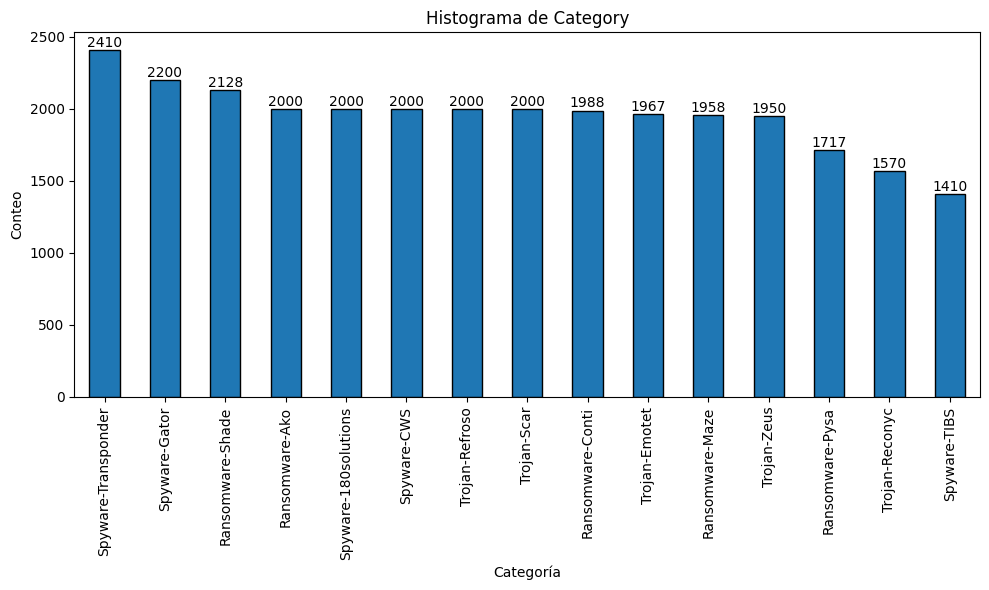

In [9]:
# Preprocesar los datos de la columna 'Category' excluyendo 'Benign'
columna_filtrada = df_limpio[df_limpio['Category'] != 'Benign'].copy()

# Truncar los nombres en la columna 'Category' hasta el segundo guion
columna_filtrada['Category'] = columna_filtrada['Category'].apply(lambda x: '-'.join(x.split('-')[:2]))

# Crear histograma con Matplotlib
plt.figure(figsize=(10, 6))

# Histograma de 'Category'
conteos = columna_filtrada['Category'].value_counts()
conteos.plot(kind='bar', edgecolor='black')
plt.title('Histograma de Category')
plt.xlabel('Categoría')
plt.ylabel('Conteo')

# Agregar etiquetas con valores en las barras
for i, cont in enumerate(conteos):
    plt.text(i, cont + 0.1, str(cont), ha='center', va='bottom')

plt.xticks(rotation=90)  # Rotar etiquetas del eje x para mejor visualización
plt.tight_layout()
plt.show()

# 11. Ahora realizaremos una serie de pasos para convertir los valores de la categoría "Class"

**Mapeo**


*   0 ➡ Benign
*   1 ➡ Malware



In [ ]:
df_limpio.head()

,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nfile,...,modules.nmodules,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.ngeneric,Class
0,Benign,45,17,10.555556,202.844444,1694,38.500000,9129,212.302326,670,...,138,389,221,26,24,116,121,87,8,Benign
1,Benign,47,19,11.531915,242.234043,2074,44.127660,11385,242.234043,840,...,138,392,222,26,24,118,122,87,8,Benign
2,Benign,40,14,14.725000,288.225000,1932,48.300000,11529,288.225000,1050,...,137,395,222,26,27,118,120,88,8,Benign
3,Benign,32,13,13.500000,264.281250,1445,45.156250,8457,264.281250,630,...,138,395,222,26,27,118,120,88,8,Benign
4,Benign,42,16,11.452381,281.333333,2067,49.214286,11816,281.333333,908,...,138,392,222,26,24,118,124,87,8,Benign


In [10]:
# Reemplazar los valores en la columna 'Class'
df_limpio['Class'] = df_limpio['Class'].replace({'Benign': 0, 'Malware': 1})

# Opcional, convertir la columna a tipo booleano
# df_limpio['Class'] = df_limpio['Class'].astype(bool)

# Muestra del DataFrame después del reemplazo
print(df_limpio['Class'].value_counts())  # Verificación de los nuevos valores únicos
df_limpio.head()  # Muestra las primeras filas del DataFrame para verificar los cambios


Class
0    29298
1    29298
Name: count, dtype: int64


,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nfile,...,modules.nmodules,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.ngeneric,Class
0,Benign,45,17,10.555556,202.844444,1694,38.500000,9129,212.302326,670,...,138,389,221,26,24,116,121,87,8,0
1,Benign,47,19,11.531915,242.234043,2074,44.127660,11385,242.234043,840,...,138,392,222,26,24,118,122,87,8,0
2,Benign,40,14,14.725000,288.225000,1932,48.300000,11529,288.225000,1050,...,137,395,222,26,27,118,120,88,8,0
3,Benign,32,13,13.500000,264.281250,1445,45.156250,8457,264.281250,630,...,138,395,222,26,27,118,120,88,8,0
4,Benign,42,16,11.452381,281.333333,2067,49.214286,11816,281.333333,908,...,138,392,222,26,24,118,124,87,8,0


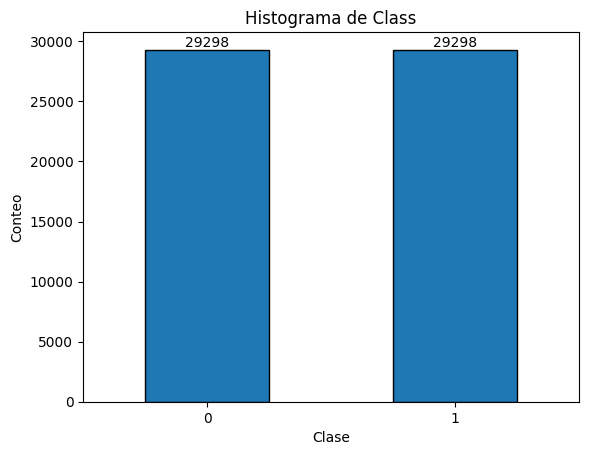

In [ ]:
# Histograma de 'Class'

# Obtener los conteos de cada clase
contadores_clase = df_limpio['Class'].value_counts()

# Crear el histograma de Class
contadores_clase.plot(kind='bar', edgecolor='black')

# Añadir anotaciones con los valores de cada barra
for i, cont in enumerate(contadores_clase):
    plt.text(i, cont + 0.1, str(cont), ha='center', va='bottom')

# Configurar título y etiquetas
plt.title('Histograma de Class')
plt.xlabel('Clase')
plt.ylabel('Conteo')
plt.xticks(rotation=0)
plt.show()

# 12. Ahora necesitamos normalizar el dataframe

In [11]:
# Normalizar el DataFrame
df_normalizado = df_limpio.apply(lambda x: (x - x.min()) / (x.max() - x.min()) if x.name not in ['Category', 'Class'] else x)

# Muestra del DataFrame normalizado
df_normalizado.head()

,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nfile,...,modules.nmodules,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.ngeneric,Class
0,Benign,0.109589,0.140625,0.587121,0.006766,0.369275,0.679940,0.005379,0.004187,0.000501,...,1.000000,0.980066,0.994012,1.0,0.85,0.978261,0.919192,0.948718,1.0,0
1,Benign,0.118721,0.171875,0.651490,0.008354,0.506311,0.802714,0.007541,0.005075,0.000712,...,1.000000,0.990033,1.000000,1.0,0.85,1.000000,0.929293,0.948718,1.0,0
2,Benign,0.086758,0.093750,0.862002,0.010208,0.455103,0.893739,0.007679,0.006439,0.000972,...,0.916667,1.000000,1.000000,1.0,1.00,1.000000,0.909091,0.974359,1.0,0
3,Benign,0.050228,0.078125,0.781241,0.009243,0.279481,0.825154,0.004736,0.005729,0.000451,...,1.000000,1.000000,1.000000,1.0,1.00,1.000000,0.909091,0.974359,1.0,0
4,Benign,0.095890,0.125000,0.646246,0.009930,0.503787,0.913685,0.007954,0.006235,0.000796,...,1.000000,0.990033,1.000000,1.0,0.85,1.000000,0.949495,0.948718,1.0,0


In [ ]:
df_normalizado.dtypes

Category                                   object
pslist.nproc                              float64
pslist.nppid                              float64
pslist.avg_threads                        float64
pslist.avg_handlers                       float64
dlllist.ndlls                             float64
dlllist.avg_dlls_per_proc                 float64
handles.nhandles                          float64
handles.avg_handles_per_proc              float64
handles.nfile                             float64
handles.nevent                            float64
handles.ndesktop                          float64
handles.nkey                              float64
handles.nthread                           float64
handles.ndirectory                        float64
handles.nsemaphore                        float64
handles.ntimer                            float64
handles.nsection                          float64
handles.nmutant                           float64
ldrmodules.not_in_load                    float64


In [ ]:
# Muestra del DataFrame resultante
df_normalizado.head()

,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nfile,...,modules.nmodules,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.ngeneric,Class
0,Benign,0.109589,0.140625,0.587121,0.006766,0.369275,0.679940,0.005379,0.004187,0.000501,...,1.000000,0.980066,0.994012,1.0,0.85,0.978261,0.919192,0.948718,1.0,0
1,Benign,0.118721,0.171875,0.651490,0.008354,0.506311,0.802714,0.007541,0.005075,0.000712,...,1.000000,0.990033,1.000000,1.0,0.85,1.000000,0.929293,0.948718,1.0,0
2,Benign,0.086758,0.093750,0.862002,0.010208,0.455103,0.893739,0.007679,0.006439,0.000972,...,0.916667,1.000000,1.000000,1.0,1.00,1.000000,0.909091,0.974359,1.0,0
3,Benign,0.050228,0.078125,0.781241,0.009243,0.279481,0.825154,0.004736,0.005729,0.000451,...,1.000000,1.000000,1.000000,1.0,1.00,1.000000,0.909091,0.974359,1.0,0
4,Benign,0.095890,0.125000,0.646246,0.009930,0.503787,0.913685,0.007954,0.006235,0.000796,...,1.000000,0.990033,1.000000,1.0,0.85,1.000000,0.949495,0.948718,1.0,0


## 12.1 Verificamos algo...

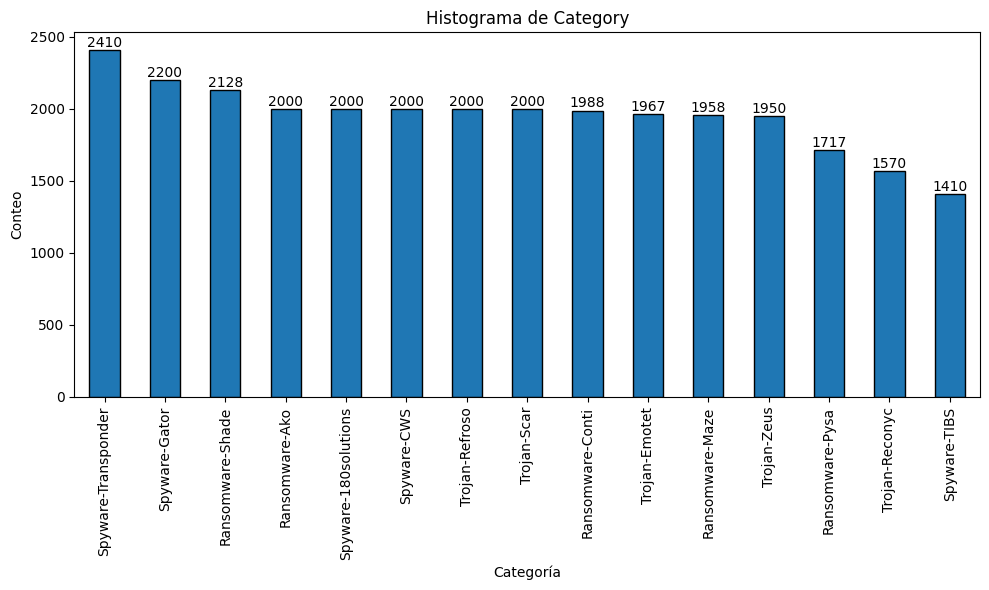

In [ ]:
# Preprocesar los datos de la columna 'Category' excluyendo 'Benign'
columna_filtrada = df_normalizado[df_normalizado['Category'] != 'Benign'].copy()

# Truncar los nombres en la columna 'Category' hasta el segundo guion
columna_filtrada['Category'] = columna_filtrada['Category'].apply(lambda x: '-'.join(x.split('-')[:2]))

# Crear histograma con Matplotlib
plt.figure(figsize=(10, 6))

# Histograma de 'Category'
conteos = columna_filtrada['Category'].value_counts()
conteos.plot(kind='bar', edgecolor='black')
plt.title('Histograma de Category')
plt.xlabel('Categoría')
plt.ylabel('Conteo')

# Agregar etiquetas con valores en las barras
for i, cont in enumerate(conteos):
    plt.text(i, cont + 0.1, str(cont), ha='center', va='bottom')

plt.xticks(rotation=90)  # Rotar etiquetas del eje x para mejor visualización
plt.tight_layout()
plt.show()

# 13. Cambiar las etiquetas de la columna de categoria de a cuerdo con la técnica de OneHot

Duda: ¿Se tienen que cambiar los labels de la categoría de Malware? ➡ Debido a que cada categoría de Malware tiene bastantes tipos de ejecición

In [ ]:
df_normalizado['Category'].value_counts()

Category
Benign                                                                                     29298
Spyware-Gator-1bdcd3b777965f67678748d2577b119a275aca9aed9549d45e64e692a54a7b5e-1.raw           2
Spyware-Gator-1bfb316482877ee42e5a5078fef44c0eb51bc44c1e88ecbccd02ce4dc4694bd3-2.raw           2
Spyware-Gator-1bfb316482877ee42e5a5078fef44c0eb51bc44c1e88ecbccd02ce4dc4694bd3-10.raw          2
Spyware-Gator-1bfb316482877ee42e5a5078fef44c0eb51bc44c1e88ecbccd02ce4dc4694bd3-1.raw           2
                                                                                           ...  
Spyware-Gator-0b25829d15dc951a44e7652fc6de9d936d7d51f29586d56dbf8fccea419252ac-6.raw           1
Spyware-Gator-0b25829d15dc951a44e7652fc6de9d936d7d51f29586d56dbf8fccea419252ac-5.raw           1
Spyware-Gator-0b25829d15dc951a44e7652fc6de9d936d7d51f29586d56dbf8fccea419252ac-4.raw           1
Spyware-Gator-0b25829d15dc951a44e7652fc6de9d936d7d51f29586d56dbf8fccea419252ac-3.raw           1
Ransomware-Shade-955d

In [12]:

# Copiamos el df para preservar los datos
df_norm_etiquetas = df_normalizado.copy()

# Se hace la magia
df_norm_etiquetas['Category'] = df_norm_etiquetas['Category'].apply(lambda x: x if x == 'Benign' else '-'.join(x.split('-')[:2]))

# Guardar el resultado en otro df
df_etiquetas_correctas = df_norm_etiquetas.copy()

df_etiquetas_correctas.head()

,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nfile,...,modules.nmodules,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.ngeneric,Class
0,Benign,0.109589,0.140625,0.587121,0.006766,0.369275,0.679940,0.005379,0.004187,0.000501,...,1.000000,0.980066,0.994012,1.0,0.85,0.978261,0.919192,0.948718,1.0,0
1,Benign,0.118721,0.171875,0.651490,0.008354,0.506311,0.802714,0.007541,0.005075,0.000712,...,1.000000,0.990033,1.000000,1.0,0.85,1.000000,0.929293,0.948718,1.0,0
2,Benign,0.086758,0.093750,0.862002,0.010208,0.455103,0.893739,0.007679,0.006439,0.000972,...,0.916667,1.000000,1.000000,1.0,1.00,1.000000,0.909091,0.974359,1.0,0
3,Benign,0.050228,0.078125,0.781241,0.009243,0.279481,0.825154,0.004736,0.005729,0.000451,...,1.000000,1.000000,1.000000,1.0,1.00,1.000000,0.909091,0.974359,1.0,0
4,Benign,0.095890,0.125000,0.646246,0.009930,0.503787,0.913685,0.007954,0.006235,0.000796,...,1.000000,0.990033,1.000000,1.0,0.85,1.000000,0.949495,0.948718,1.0,0


In [13]:
df_etiquetas_correctas['Category'].value_counts()

Category
Benign                  29298
Spyware-Transponder      2410
Spyware-Gator            2200
Ransomware-Shade         2128
Ransomware-Ako           2000
Spyware-180solutions     2000
Spyware-CWS              2000
Trojan-Refroso           2000
Trojan-Scar              2000
Ransomware-Conti         1988
Trojan-Emotet            1967
Ransomware-Maze          1958
Trojan-Zeus              1950
Ransomware-Pysa          1717
Trojan-Reconyc           1570
Spyware-TIBS             1410
Name: count, dtype: int64

Ahora que ya lo cambiamos, procedemos a realizar el One-Hot Encoding como se vió en este video [Video que Explica el One-Hot Encoding](https://www.youtube.com/watch?v=DAQhQFp-sCg)

In [14]:
#Category_dummies = pd.get_dummies(df_etiquetas_correctas['Category'])
from sklearn.preprocessing import OneHotEncoder

# Creamos una copia del dataframe original
df = df_etiquetas_correctas.copy()

# Inicializar y ajustar el codificador one-hot
encoder = OneHotEncoder()

# Ajustar y transformar la columna 'Category'
X = df['Category'].values.reshape(-1, 1)
X_codificado = encoder.fit_transform(X)

# Obtener las catagorias codificadas
categorias_codificadas = encoder.categories_[0]

#Creamos un dataframe con las columnas codificadas
df_columnas_codificadas= pd.DataFrame(X_codificado.toarray(), columns=categorias_codificadas, index=df.index)

# Concatenamos
df_one_hot_FINAL = pd.concat([df, df_columnas_codificadas], axis=1)

# Eliminamos la columna 'Category'
df_one_hot_FINAL = df_one_hot_FINAL.drop('Category', axis = 1)

df_one_hot_FINAL.head()


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nfile,handles.nevent,...,Spyware-180solutions,Spyware-CWS,Spyware-Gator,Spyware-TIBS,Spyware-Transponder,Trojan-Emotet,Trojan-Reconyc,Trojan-Refroso,Trojan-Scar,Trojan-Zeus
0,0.109589,0.140625,0.587121,0.006766,0.369275,0.679940,0.005379,0.004187,0.000501,0.316922,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.118721,0.171875,0.651490,0.008354,0.506311,0.802714,0.007541,0.005075,0.000712,0.403552,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.086758,0.093750,0.862002,0.010208,0.455103,0.893739,0.007679,0.006439,0.000972,0.437482,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.050228,0.078125,0.781241,0.009243,0.279481,0.825154,0.004736,0.005729,0.000451,0.288045,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.095890,0.125000,0.646246,0.009930,0.503787,0.913685,0.007954,0.006235,0.000796,0.414092,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**NOTA** Se supone que al aplicar One-Hot Encoding, se elimina la columna categorica y nos quedamos con las que contatenamos anteriormente.

In [60]:
df_one_hot_FINAL.shape
df_one_hot_FINAL.dtypes

pslist.nproc                              float64
pslist.nppid                              float64
pslist.avg_threads                        float64
pslist.avg_handlers                       float64
dlllist.ndlls                             float64
dlllist.avg_dlls_per_proc                 float64
handles.nhandles                          float64
handles.avg_handles_per_proc              float64
handles.nfile                             float64
handles.nevent                            float64
handles.ndesktop                          float64
handles.nkey                              float64
handles.nthread                           float64
handles.ndirectory                        float64
handles.nsemaphore                        float64
handles.ntimer                            float64
handles.nsection                          float64
handles.nmutant                           float64
ldrmodules.not_in_load                    float64
ldrmodules.not_in_init                    float64


## 13.1 Label encoding ?¿

OK, de acuerdo con lo que le entendí al profesor, esto es lo que se tiene que realizar.
+ Benign ➡              1000000000000000
+ Spyware-Transponder ➡ 0100000000000000
+ Spyware-Gator ➡       0010000000000000
+ Ransomware-Shade ➡    0001000000000000
+ Ransomware-Ako ➡      0000100000000000
+ Spyware-180solutions ➡0000010000000000
+ Spyware-CWS ➡         0000001000000000
+ Trojan-Refroso ➡      0000000100000000
+ Trojan-Scar ➡         0000000010000000
+ Ransomware-Conti ➡    0000000001000000
+ Trojan-Emotet ➡       0000000000100000
+ Ransomware-Maze ➡     0000000000010000
+ Trojan-Zeus ➡         0000000000001000
+ Ransomware-Pysa ➡     0000000000000100
+ Trojan-Reconyc ➡      0000000000000010
+ Spyware-TIBS ➡        0000000000000001

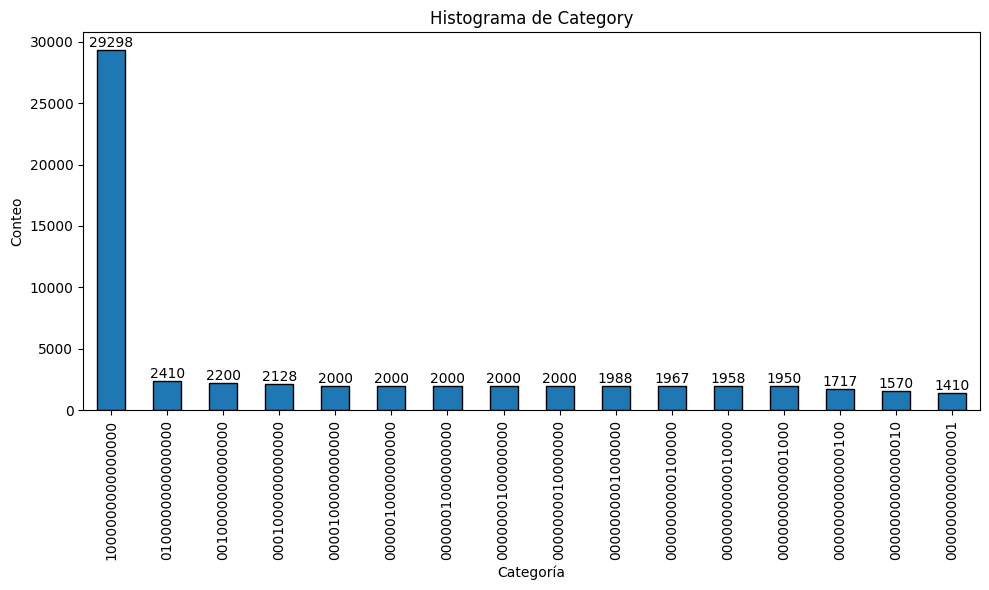

In [ ]:
df_label_encoding = df_etiquetas_correctas.copy()

# creamos un diccionario
correspondencia_etiquetas = {
    'Benign': '1000000000000000',
    'Spyware-Transponder': '0100000000000000',
    'Spyware-Gator': '0010000000000000',
    'Ransomware-Shade': '0001000000000000',
    'Ransomware-Ako': '0000100000000000',
    'Spyware-180solutions': '0000010000000000',
    'Spyware-CWS': '0000001000000000',
    'Trojan-Refroso': '0000000100000000',
    'Trojan-Scar': '0000000010000000',
    'Ransomware-Conti': '0000000001000000',
    'Trojan-Emotet': '0000000000100000',
    'Ransomware-Maze': '0000000000010000',
    'Trojan-Zeus': '0000000000001000',
    'Ransomware-Pysa': '0000000000000100',
    'Trojan-Reconyc': '0000000000000010',
    'Spyware-TIBS': '0000000000000001'
}

# Reemplazamos
df_label_encoding['Category'] = df_label_encoding['Category'].replace(correspondencia_etiquetas)

# verificamos
plt.figure(figsize=(10, 6))
total = df_label_encoding['Category'].value_counts()
total.plot(kind='bar', edgecolor='black')
plt.title('Histograma de Category')
plt.xlabel('Categoría')
plt.ylabel('Conteo')

# Agregar etiquetas con valores en las barras
for i, cont in enumerate(total):
    plt.text(i, cont + 0.1, str(cont), ha='center', va='bottom')

plt.xticks(rotation=90)  # Rotar etiquetas del eje x para mejor visualización
plt.tight_layout()
plt.show()

# DUDA: ¿Entonces cuál tomamos?

# 14. Particionar el dataframe en dos partes Training (80%) y Test (20%)

Para hacer esto hay dos formas diferentes


1.   Utilizar la libreria sklearn.model_selection (importamos *train_test_split*)
2.   Particionarlos usando las librerias pandas y numpy



## 14.1 Libreria sklearn





### 14.1.1 Utilizamos el dataframe de one_hot_FINAL

In [15]:
from sklearn.model_selection import train_test_split

# Dividimos el df en training (80%) y test (20%) estratificando según la columna 'target'
df_train_OHF, df_test_OHF = train_test_split(df_one_hot_FINAL.copy(), test_size=0.2, random_state=42, stratify=df_one_hot_FINAL['Class'])

# Mostrar la forma de los conjuntos de entrenamiento y prueba
print("Tamaño del conjunto de entrenamiento:", len(df_train_OHF))
print("Tamaño del conjunto de prueba:", len(df_test_OHF))

Tamaño del conjunto de entrenamiento: 46876
Tamaño del conjunto de prueba: 11720


In [ ]:
df_train_OHF.head()

,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nfile,handles.nevent,...,Spyware-180solutions,Spyware-CWS,Spyware-Gator,Spyware-TIBS,Spyware-Transponder,Trojan-Emotet,Trojan-Reconyc,Trojan-Refroso,Trojan-Scar,Trojan-Zeus
9434,0.086758,0.062500,0.742625,0.010359,0.474216,0.922645,0.007822,0.006551,0.001049,0.451343,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26912,0.091324,0.062500,0.810390,0.011180,0.539127,0.992278,0.008902,0.007155,0.001066,0.506353,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47022,0.063927,0.109375,0.674815,0.006419,0.242697,0.677135,0.003146,0.003651,0.000409,0.166907,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
19371,0.105023,0.062500,0.704435,0.009894,0.562207,0.927560,0.008651,0.006208,0.001016,0.503898,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17129,0.086758,0.062500,0.737168,0.010377,0.474216,0.922645,0.007840,0.006564,0.001042,0.454375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_test_OHF.head()

,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nfile,handles.nevent,...,Spyware-180solutions,Spyware-CWS,Spyware-Gator,Spyware-TIBS,Spyware-Transponder,Trojan-Emotet,Trojan-Reconyc,Trojan-Refroso,Trojan-Scar,Trojan-Zeus
50843,0.086758,0.140625,0.530716,0.006991,0.324558,0.696302,0.004621,0.004072,0.000466,0.279238,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
37832,0.091324,0.125000,0.626070,0.007248,0.347638,0.709471,0.005070,0.004261,0.000480,0.298585,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6645,0.095890,0.062500,0.771045,0.010797,0.549946,0.980173,0.008819,0.006873,0.001028,0.506208,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27932,0.082192,0.062500,0.746429,0.010381,0.458348,0.925792,0.007563,0.006567,0.000948,0.444124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28932,0.091324,0.093750,0.735630,0.010237,0.497656,0.930827,0.007982,0.006461,0.000971,0.457551,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 14.1.2 Utilizamos el dataframe de label_encoding

In [ ]:
# Dividimos el df en training (80%) y test (20%)
df_train_LE, df_test_LE = train_test_split(df_label_encoding.copy(), test_size=0.2, random_state=42)

# Mostrar la forma de los conjuntos de entrenamiento y prueba
print("Tamaño del conjunto de entrenamiento:", len(df_train_LE))
print("Tamaño del conjunto de prueba:", len(df_test_LE))

NameError: name 'df_label_encoding' is not defined

In [ ]:
df_train_LE.head()

,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nfile,...,modules.nmodules,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.ngeneric,Class
55078,0000000000000100,0.086758,0.125000,0.520827,0.006770,0.304364,0.665759,0.004410,0.003909,0.000467,...,1.0,0.980066,0.994012,1.0,0.85,0.978261,0.898990,0.948718,1.0,1
46970,0000000000100000,0.105023,0.140625,0.502547,0.006576,0.358457,0.665065,0.004985,0.003766,0.000496,...,1.0,0.980066,0.994012,1.0,0.85,0.978261,0.929293,0.923077,1.0,1
29180,1000000000000000,0.045662,0.046875,0.754581,0.010553,0.328164,0.926456,0.005658,0.006981,0.000578,...,1.0,1.000000,1.000000,1.0,1.00,1.000000,0.939394,0.974359,1.0,0
46424,0000000000100000,0.077626,0.109375,0.562639,0.007264,0.298233,0.699459,0.004467,0.004273,0.000466,...,1.0,0.980066,0.994012,1.0,0.85,0.978261,0.909091,0.923077,1.0,1
39359,0000001000000000,0.105023,0.125000,0.598442,0.007050,0.377209,0.690848,0.005482,0.004261,0.000555,...,1.0,0.980066,0.994012,1.0,0.85,0.978261,0.939394,0.923077,1.0,1


In [ ]:
df_test_LE.head()

,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nfile,...,modules.nmodules,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.ngeneric,Class
29918,0000000001000000,0.077626,0.109375,0.557434,0.007203,0.295709,0.695441,0.004413,0.004228,0.000457,...,1.0,0.980066,0.994012,1.0,0.85,0.978261,0.888889,0.923077,1.0,1
5034,1000000000000000,0.091324,0.062500,0.774109,0.010939,0.533357,0.983608,0.008667,0.006978,0.001020,...,1.0,1.000000,1.000000,1.0,1.00,1.000000,0.939394,0.974359,1.0,0
38101,0000001000000000,0.095890,0.125000,0.580319,0.007277,0.350884,0.693445,0.005307,0.004439,0.000728,...,1.0,0.980066,0.994012,1.0,0.85,0.978261,0.929293,0.948718,1.0,1
17050,1000000000000000,0.091324,0.093750,0.728825,0.010217,0.497656,0.930827,0.007964,0.006446,0.000971,...,1.0,1.000000,1.000000,1.0,1.00,1.000000,0.939394,0.974359,1.0,0
35147,0001000000000000,0.086758,0.125000,0.515883,0.006817,0.300397,0.659760,0.004455,0.003944,0.000478,...,1.0,0.980066,0.994012,1.0,0.85,0.978261,0.898990,0.948718,1.0,1


# 15. Desarrollo de la red

Para probar una red neuronal, se debe de hacer una sola neurona con 16 entradas (son los tipos de paquete) 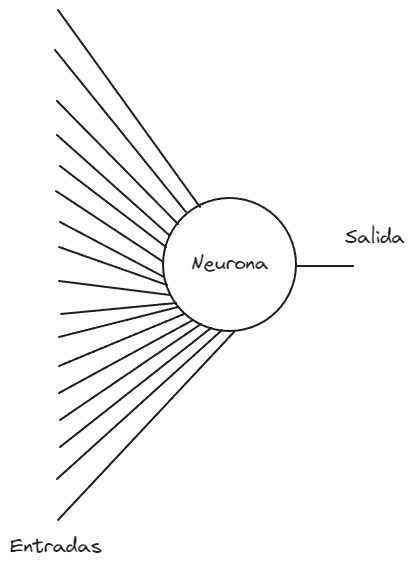

In [16]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [17]:
# Selección de las columnas one-hot del tipo de paquete
OH_cols = [col for col in df_one_hot_FINAL.columns if 'Benign' in col or 'Ransomware' in col or 'Spyware' in col or 'Trojan' in col]

print(OH_cols)

#X = df_one_hot_FINAL.drop(['Class'], axis=1) # Selecciona solo las 16 columnas one-hot

#print(X)
#X.shape

['Benign', 'Ransomware-Ako', 'Ransomware-Conti', 'Ransomware-Maze', 'Ransomware-Pysa', 'Ransomware-Shade', 'Spyware-180solutions', 'Spyware-CWS', 'Spyware-Gator', 'Spyware-TIBS', 'Spyware-Transponder', 'Trojan-Emotet', 'Trojan-Reconyc', 'Trojan-Refroso', 'Trojan-Scar', 'Trojan-Zeus']


In [18]:
# Separamos las caracteristicas y las etiquetas
X = df_one_hot_FINAL.drop(['Class'], axis=1).values # Caracteristicas
#X = df_one_hot_FINAL.drop(OH_cols, axis=1).values # Caracteristicas
y = df_one_hot_FINAL['Class'].values #Etiquetas
X.shape

(58596, 59)

In [19]:
# Caracteristicas de entrada (entradas de la neurona)
dimension_inputs = 59

In [20]:
# Division de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df_one_hot_FINAL['Class'])

# Mostrar la forma de los conjuntos de entrenamiento y prueba (80 - 20)
print("Tamaño del conjunto de entrenamiento x:", len(X_train))
print("Tamaño del conjunto de prueba x:", len(X_test))
print("Tamaño del conjunto de entrenamiento y:", len(y_train))
print("Tamaño del conjunto de prueba y:", len(y_test))

Tamaño del conjunto de entrenamiento x: 46876
Tamaño del conjunto de prueba x: 11720
Tamaño del conjunto de entrenamiento y: 46876
Tamaño del conjunto de prueba y: 11720


In [67]:
#Creamos el modelo secuencial
modelo = Sequential()
modelo.add(Dense(1, input_dim=dimension_inputs, activation='sigmoid'))

In [68]:
# Compilamos el modelo
modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Entrenamiento del modelo
modelo.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/100
1465/1465 [==============================] - 6s 3ms/step - loss: 0.3825 - accuracy: 0.9525 - val_loss: 0.1912 - val_accuracy: 0.9987
Epoch 2/100
1465/1465 [==============================] - 3s 2ms/step - loss: 0.1227 - accuracy: 0.9985 - val_loss: 0.0765 - val_accuracy: 0.9989
Epoch 3/100
1465/1465 [==============================] - 3s 2ms/step - loss: 0.0539 - accuracy: 0.9990 - val_loss: 0.0367 - val_accuracy: 0.9995
Epoch 4/100
1465/1465 [==============================] - 3s 2ms/step - loss: 0.0270 - accuracy: 0.9999 - val_loss: 0.0191 - val_accuracy: 1.0000
Epoch 5/100
1465/1465 [==============================] - 3s 2ms/step - loss: 0.0144 - accuracy: 1.0000 - val_loss: 0.0103 - val_accuracy: 1.0000
Epoch 6/100
1465/1465 [==============================] - 4s 3ms/step - loss: 0.0079 - accuracy: 1.0000 - val_loss: 0.0058 - val_accuracy: 1.0000
Epoch 7/100
1465/1465 [==============================] - 3s 2ms/step - loss: 0.0045 - accuracy: 1.0000 - val_loss: 0.0033 - val_ac

In [ ]:
# Evaluamos al modelo
perdida, exactitud = modelo.evaluate(X_test, y_test)
print(f'Perdida en la prueba: {perdida:.4f}')
print(f'Exactitud en la prueba: {exactitud:.4f}')

367/367 [==============================] - 1s 1ms/step - loss: 7.7573e-09 - accuracy: 1.0000
Perdida en la prueba: 0.0000
Exactitud en la prueba: 1.0000


# 16. Red Neuronal de prueba 1

In [21]:
#Eliminacion de columnas one-hot y 'Class'
one_hot_cols = [col for col in df_one_hot_FINAL.columns if 'Benign' in col or 'Ransomware' in col or 'Spyware' in col or 'Trojan' in col]
X_1 = df_one_hot_FINAL.drop(['Class'] + one_hot_cols, axis=1).values


In [22]:
# obtención de las etiquetas
y_1 = df_one_hot_FINAL['Class'].values

In [23]:
# Obtener la forma de los datos
print("Forma de X_1:", X_1.shape)
print("Forma de y_1:", y_1.shape)

Forma de X_1: (58596, 43)
Forma de y_1: (58596,)


In [24]:
# Obtener el número de características de entrada
input_dim = X.shape[1]

In [25]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [74]:
# Crear el modelo
model = Sequential()
model.add(Dense(64, input_dim=input_dim, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # La salida tiene que ser la misma que el shape del target (y)

In [ ]:
# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# Entrenar el modelo
epochs = 100  # Número de épocas (puedes ajustarlo según tus necesidades)
batch_size = 32  # Tamaño del lote (puedes ajustarlo según tus necesidades)
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test))


Epoch 1/100
1465/1465 [==============================] - 5s 3ms/step - loss: 0.0224 - accuracy: 0.9988 - val_loss: 5.5763e-06 - val_accuracy: 1.0000
Epoch 2/100
1465/1465 [==============================] - 3s 2ms/step - loss: 3.8186e-06 - accuracy: 1.0000 - val_loss: 2.3347e-06 - val_accuracy: 1.0000
Epoch 3/100
1465/1465 [==============================] - 5s 4ms/step - loss: 1.8596e-06 - accuracy: 1.0000 - val_loss: 1.1118e-06 - val_accuracy: 1.0000
Epoch 4/100
1465/1465 [==============================] - 4s 3ms/step - loss: 8.8738e-07 - accuracy: 1.0000 - val_loss: 5.0396e-07 - val_accuracy: 1.0000
Epoch 5/100
1465/1465 [==============================] - 3s 2ms/step - loss: 4.3850e-07 - accuracy: 1.0000 - val_loss: 2.4020e-07 - val_accuracy: 1.0000
Epoch 6/100
1465/1465 [==============================] - 4s 2ms/step - loss: 2.1769e-07 - accuracy: 1.0000 - val_loss: 1.8909e-07 - val_accuracy: 1.0000
Epoch 7/100
1465/1465 [==============================] - 5s 4ms/step - loss: 1.0636e-0

In [ ]:
# Evaluar el modelo
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test loss: {loss:.4f}')
print(f'Test accuracy: {accuracy:.4f}')

367/367 [==============================] - 1s 2ms/step - loss: 3.5772e-10 - accuracy: 1.0000
Test loss: 0.0000
Test accuracy: 1.0000


In [ ]:

# Hacer predicciones

predictions = model.predict(X_test)
print(predictions)
predictions.shape


367/367 [==============================] - 1s 2ms/step
[[1.0000000e+00]
 [1.0000000e+00]
 [1.5320931e-13]
 ...
 [1.0000000e+00]
 [1.0000000e+00]
 [1.0000000e+00]]


(11720, 1)

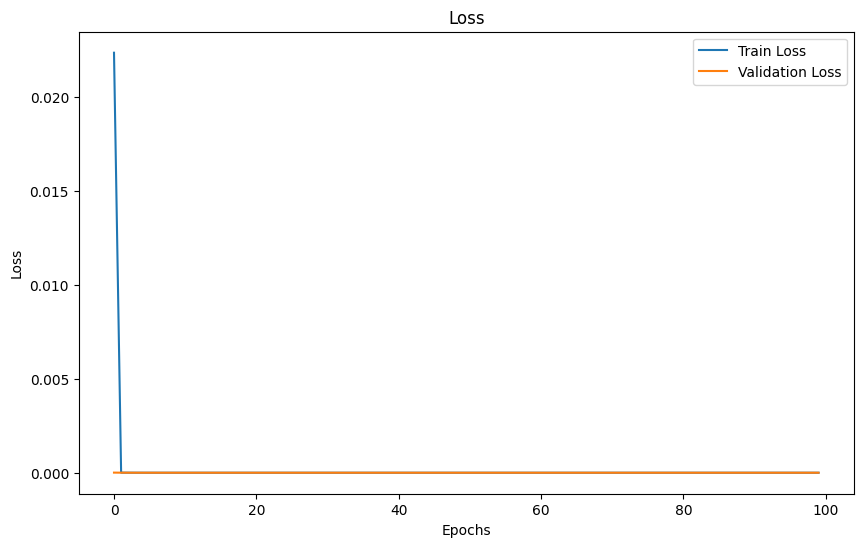

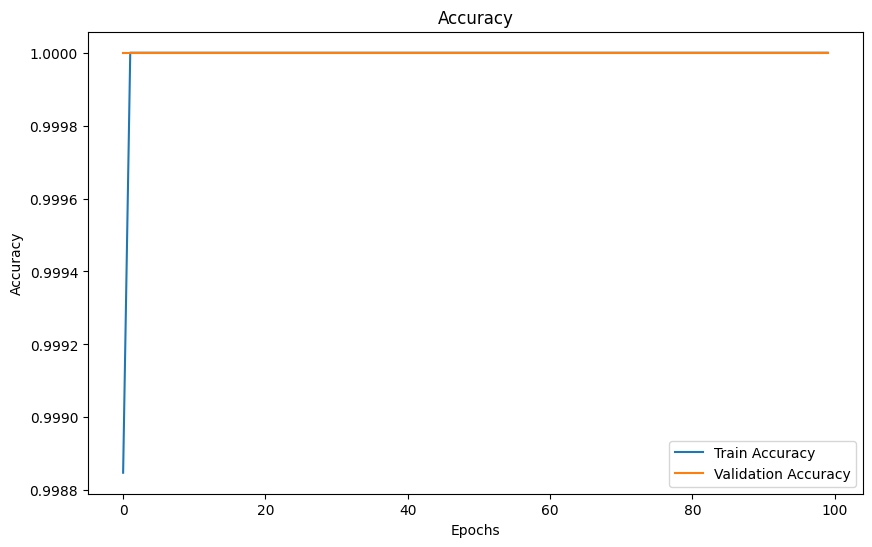

In [ ]:
# Graficar loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Graficar accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.show()

In [ ]:

import plotly.graph_objects as go

# Graficar loss
fig = go.Figure()
fig.add_trace(go.Scatter(x=list(range(len(history.history['loss']))),
                         y=history.history['loss'],
                         mode='lines',
                         name='Train Loss'))
fig.add_trace(go.Scatter(x=list(range(len(history.history['val_loss']))),
                         y=history.history['val_loss'],
                         mode='lines',
                         name='Validation Loss'))
fig.update_layout(title='Loss',
                  xaxis_title='Epochs',
                  yaxis_title='Loss')
fig.show()

# Graficar accuracy
fig = go.Figure()
fig.add_trace(go.Scatter(x=list(range(len(history.history['accuracy']))),
                         y=history.history['accuracy'],
                         mode='lines',
                         name='Train Accuracy'))
fig.add_trace(go.Scatter(x=list(range(len(history.history['val_accuracy']))),
                         y=history.history['val_accuracy'],
                         mode='lines',
                         name='Validation Accuracy'))
fig.update_layout(title='Accuracy',
                  xaxis_title='Epochs',
                  yaxis_title='Accuracy')
fig.show()

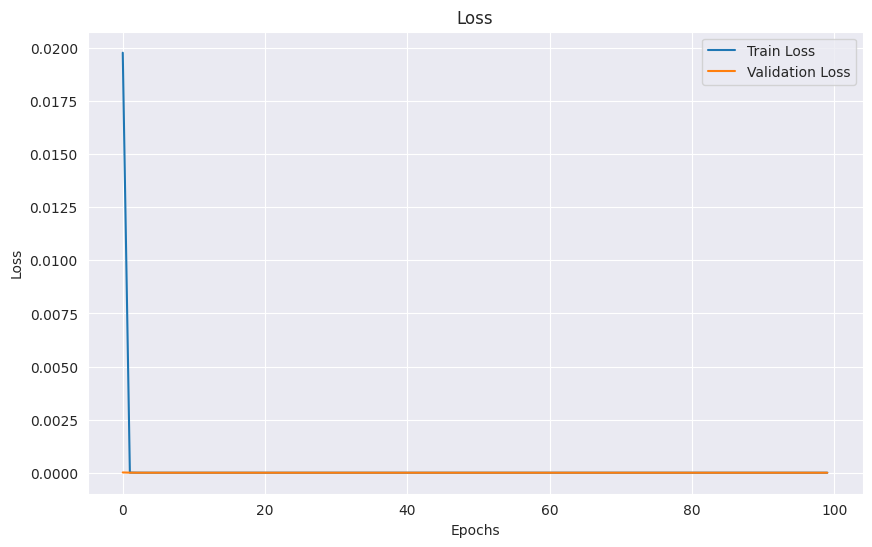

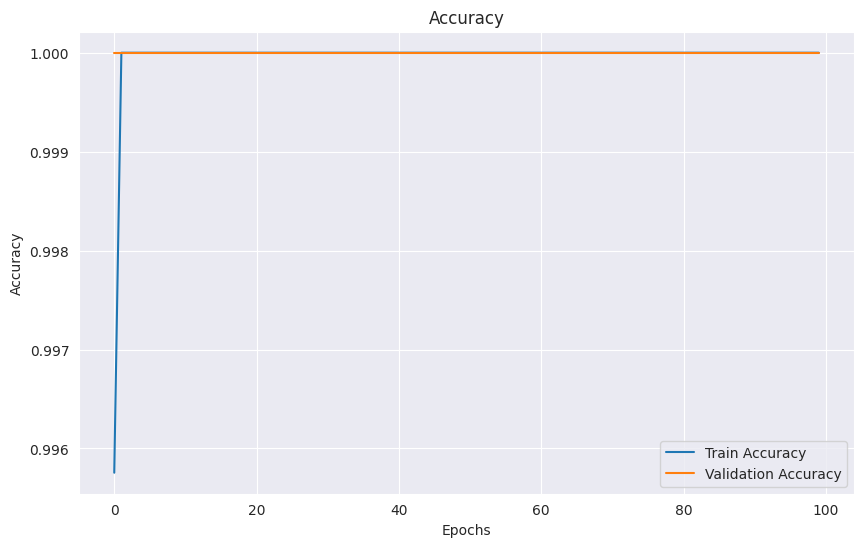

In [ ]:
import seaborn as sns

# Graficar loss
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
sns.lineplot(x=range(len(history.history['loss'])), y=history.history['loss'], label='Train Loss')
sns.lineplot(x=range(len(history.history['val_loss'])), y=history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Graficar accuracy
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
sns.lineplot(x=range(len(history.history['accuracy'])), y=history.history['accuracy'], label='Train Accuracy')
sns.lineplot(x=range(len(history.history['val_accuracy'])), y=history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 17. Red neuronal con softmax

In [26]:
# Eliminar las columnas one-hot y 'Class'
one_hot_cols = [col for col in df_one_hot_FINAL.columns if 'Benign' in col or 'Ransomware' in col or 'Spyware' in col or 'Trojan' in col]
X_2 = df_one_hot_FINAL.drop(['Class'] + one_hot_cols, axis=1).values


In [27]:
# Obtener las etiquetas
y_2 = df_one_hot_FINAL[one_hot_cols].values

In [28]:
# Obtener la forma de los datos
print("Forma de X:", X_2.shape)
print("Forma de y:", y_2.shape)

Forma de X: (58596, 43)
Forma de y: (58596, 16)


In [29]:
# Obtener el número de características de entrada
input_dim_2 = X_2.shape[1]

In [30]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42, stratify=y_2)



In [ ]:
# Crear el modelo
model_2 = Sequential()
model_2.add(Dense(64, input_dim=input_dim_2, activation='relu'))
model_2.add(Dense(32, activation='relu'))
model_2.add(Dense(16, activation='softmax'))

In [ ]:
# Compilar el modelo
model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
# Entrenar el modelo
epochs = 100  # Número de épocas (puedes ajustarlo según tus necesidades)
batch_size = 32  # Tamaño del lote (puedes ajustarlo según tus necesidades)
history = model_2.fit(X_train_2, y_train_2, epochs=epochs, batch_size=batch_size, validation_data=(X_test_2, y_test_2))



Epoch 1/100
1465/1465 [==============================] - 5s 3ms/step - loss: 0.1435 - accuracy: 0.5107 - val_loss: 0.1181 - val_accuracy: 0.5443
Epoch 2/100
1465/1465 [==============================] - 5s 3ms/step - loss: 0.1158 - accuracy: 0.5463 - val_loss: 0.1139 - val_accuracy: 0.5555
Epoch 3/100
1465/1465 [==============================] - 3s 2ms/step - loss: 0.1128 - accuracy: 0.5532 - val_loss: 0.1112 - val_accuracy: 0.5620
Epoch 4/100
1465/1465 [==============================] - 3s 2ms/step - loss: 0.1115 - accuracy: 0.5610 - val_loss: 0.1106 - val_accuracy: 0.5715
Epoch 5/100
1465/1465 [==============================] - 3s 2ms/step - loss: 0.1107 - accuracy: 0.5678 - val_loss: 0.1099 - val_accuracy: 0.5683
Epoch 6/100
1465/1465 [==============================] - 4s 3ms/step - loss: 0.1099 - accuracy: 0.5713 - val_loss: 0.1095 - val_accuracy: 0.5741
Epoch 7/100
1465/1465 [==============================] - 3s 2ms/step - loss: 0.1092 - accuracy: 0.5737 - val_loss: 0.1085 - val_ac

In [ ]:
# Evaluar el modelo
loss_2, accuracy_2 = model_2.evaluate(X_test_2, y_test_2)
print(f'Test loss: {loss_2:.4f}')
print(f'Test accuracy: {accuracy_2:.4f}')

367/367 [==============================] - 1s 3ms/step - loss: 0.0972 - accuracy: 0.6289
Test loss: 0.0972
Test accuracy: 0.6289


In [ ]:
# Hacer predicciones

predictions_2 = model_2.predict(X_test_2)
print(predictions_2)

367/367 [==============================] - 1s 2ms/step
[[9.99999940e-01 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 9.98345898e-38]
 [2.56324802e-05 5.47744706e-02 7.23628476e-02 ... 1.22873504e-02
  2.18547121e-01 4.17406857e-02]
 [1.32247875e-08 4.91994917e-02 6.22108281e-02 ... 7.99979568e-02
  8.82507637e-02 7.08974674e-02]
 ...
 [9.99999940e-01 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 7.97052116e-27]
 [9.99999940e-01 4.44106845e-36 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 1.49620852e-24]
 [9.99999940e-01 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]


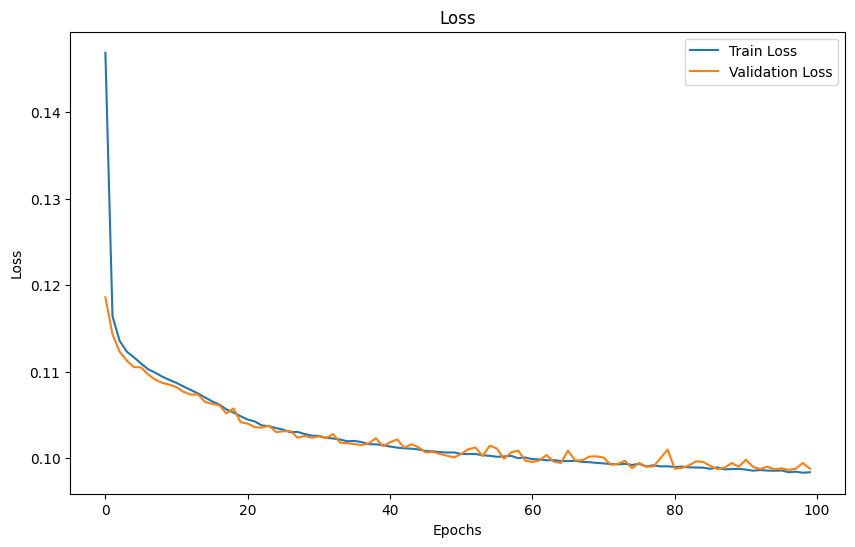

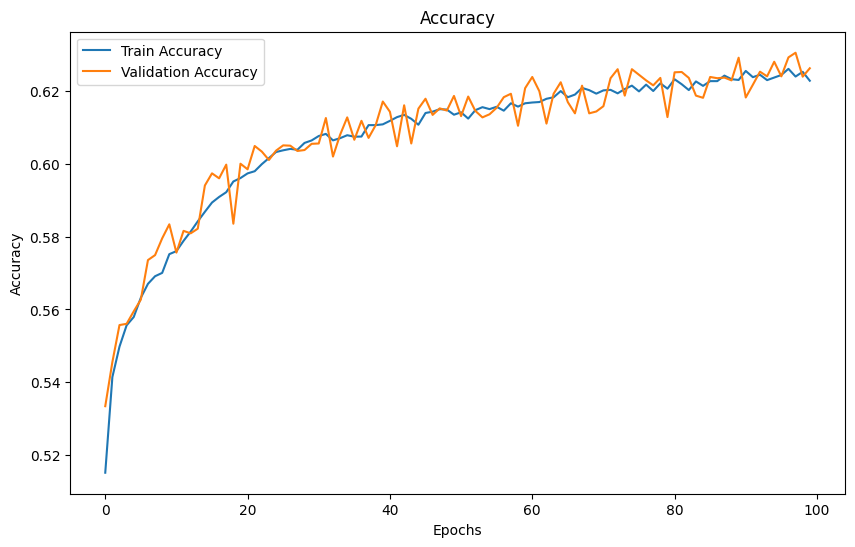

In [ ]:
# Graficar loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Graficar accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.show()

In [ ]:
# Entrenar el modelo
epochs = 200  # Número de épocas (puedes ajustarlo según tus necesidades)
batch_size = 32  # Tamaño del lote (puedes ajustarlo según tus necesidades)
history = model_2.fit(X_train_2, y_train_2, epochs=epochs, batch_size=batch_size, validation_data=(X_test_2, y_test_2))



Epoch 1/200
1465/1465 [==============================] - 6s 3ms/step - loss: 0.1463 - accuracy: 0.5170 - val_loss: 0.1176 - val_accuracy: 0.5414
Epoch 2/200
1465/1465 [==============================] - 6s 4ms/step - loss: 0.1153 - accuracy: 0.5499 - val_loss: 0.1130 - val_accuracy: 0.5603
Epoch 3/200
1465/1465 [==============================] - 5s 4ms/step - loss: 0.1126 - accuracy: 0.5586 - val_loss: 0.1117 - val_accuracy: 0.5612
Epoch 4/200
1465/1465 [==============================] - 6s 4ms/step - loss: 0.1114 - accuracy: 0.5626 - val_loss: 0.1104 - val_accuracy: 0.5692
Epoch 5/200
1465/1465 [==============================] - 6s 4ms/step - loss: 0.1106 - accuracy: 0.5682 - val_loss: 0.1099 - val_accuracy: 0.5749
Epoch 6/200
1465/1465 [==============================] - 6s 4ms/step - loss: 0.1100 - accuracy: 0.5704 - val_loss: 0.1097 - val_accuracy: 0.5706
Epoch 7/200
1465/1465 [==============================] - 6s 4ms/step - loss: 0.1096 - accuracy: 0.5693 - val_loss: 0.1090 - val_ac

In [ ]:
# Evaluar el modelo
loss_2, accuracy_2 = model_2.evaluate(X_test_2, y_test_2)
print(f'Test loss: {loss_2:.4f}')
print(f'Test accuracy: {accuracy_2:.4f}')

367/367 [==============================] - 1s 2ms/step - loss: 0.0965 - accuracy: 0.6380
Test loss: 0.0965
Test accuracy: 0.6380


In [ ]:
# Hacer predicciones

predictions_2 = model_2.predict(X_test_2)
print(predictions_2)

367/367 [==============================] - 1s 3ms/step
[[9.9999994e-01 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 [6.2142913e-06 3.3454228e-02 7.0911430e-02 ... 7.3994920e-03
  1.5747075e-01 7.3288097e-03]
 [9.1823310e-08 6.5638095e-02 6.5333158e-02 ... 5.3261865e-02
  6.5073855e-02 9.2947446e-02]
 ...
 [9.9999994e-01 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 [9.9999994e-01 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 [9.9999994e-01 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]]


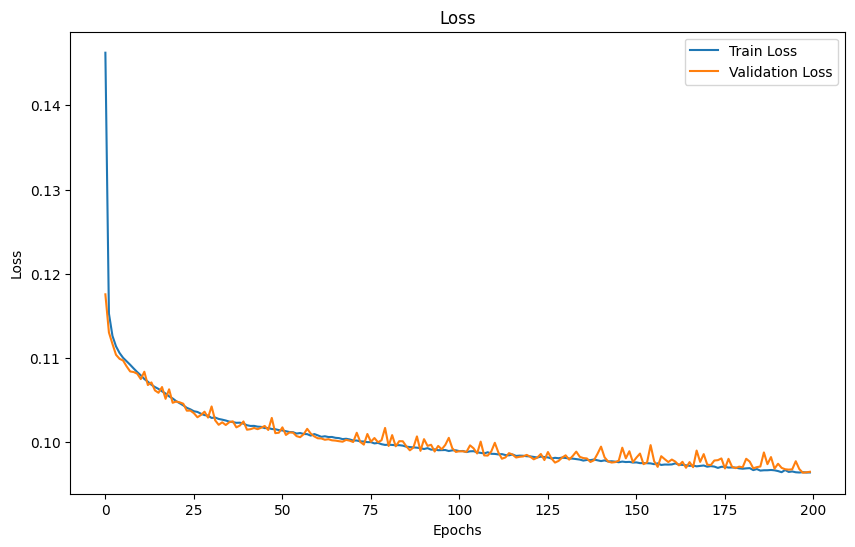

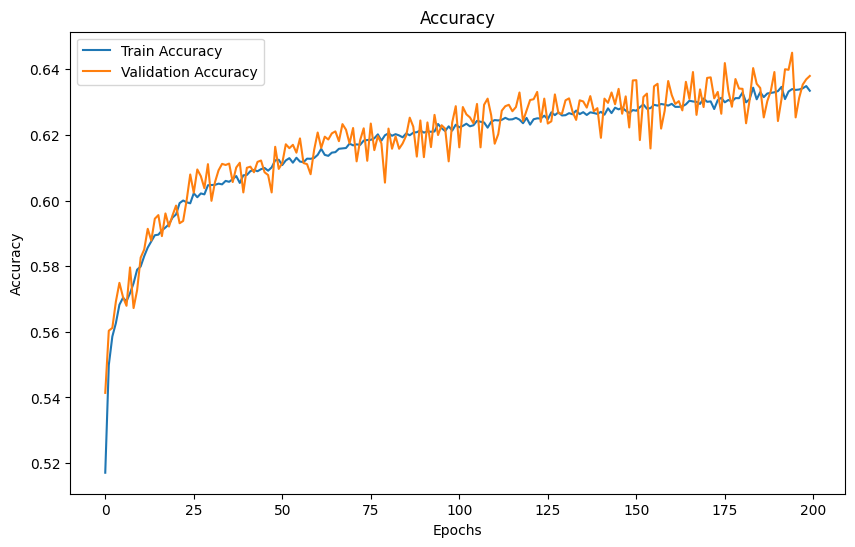

In [ ]:
# Graficar loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Graficar accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.show()

In [ ]:
# Crear el modelo
model_3 = Sequential()
model_3.add(Dense(64, input_dim=input_dim_2, activation='relu'))
model_3.add(Dense(32, activation='relu'))
model_3.add(Dense(16, activation='softmax'))

# Compilar el modelo
model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
epochs = 400  # Número de épocas (puedes ajustarlo según tus necesidades)
batch_size = 32  # Tamaño del lote (puedes ajustarlo según tus necesidades)
history = model_3.fit(X_train_2, y_train_2, epochs=epochs, batch_size=batch_size, validation_data=(X_test_2, y_test_2))


Epoch 1/400
1465/1465 [==============================] - 5s 3ms/step - loss: 0.1418 - accuracy: 0.5146 - val_loss: 0.1155 - val_accuracy: 0.5542
Epoch 2/400
1465/1465 [==============================] - 3s 2ms/step - loss: 0.1141 - accuracy: 0.5530 - val_loss: 0.1122 - val_accuracy: 0.5664
Epoch 3/400
1465/1465 [==============================] - 5s 3ms/step - loss: 0.1122 - accuracy: 0.5606 - val_loss: 0.1124 - val_accuracy: 0.5646
Epoch 4/400
1465/1465 [==============================] - 3s 2ms/step - loss: 0.1113 - accuracy: 0.5644 - val_loss: 0.1105 - val_accuracy: 0.5675
Epoch 5/400
1465/1465 [==============================] - 3s 2ms/step - loss: 0.1106 - accuracy: 0.5696 - val_loss: 0.1097 - val_accuracy: 0.5726
Epoch 6/400
1465/1465 [==============================] - 4s 3ms/step - loss: 0.1100 - accuracy: 0.5715 - val_loss: 0.1092 - val_accuracy: 0.5723
Epoch 7/400
1465/1465 [==============================] - 5s 3ms/step - loss: 0.1094 - accuracy: 0.5750 - val_loss: 0.1093 - val_ac

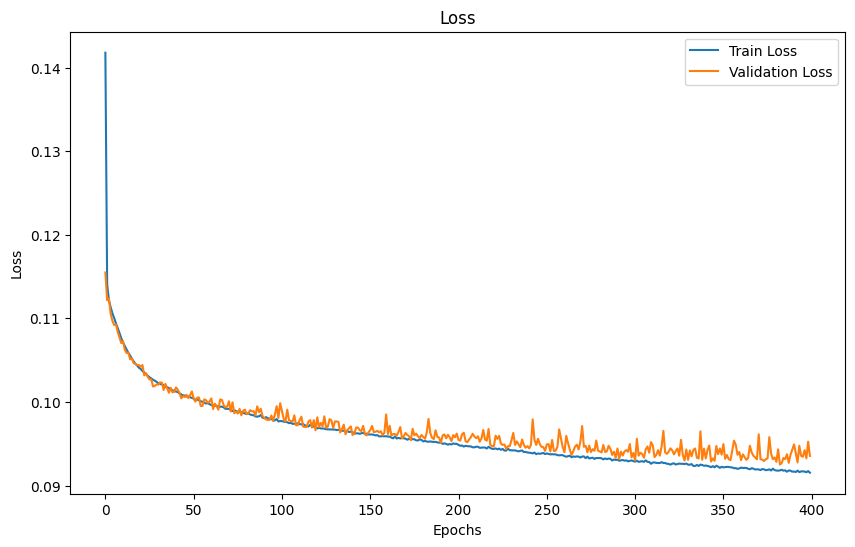

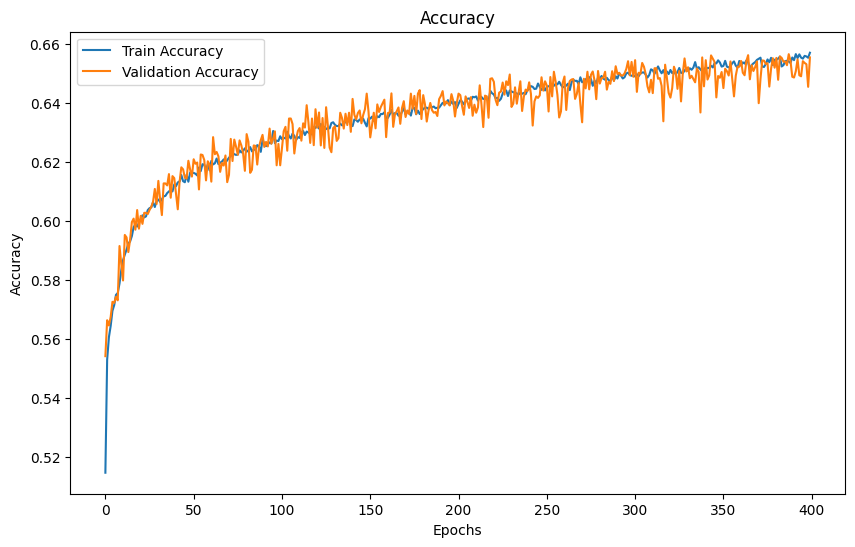

In [ ]:
# Graficar loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Graficar accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.show()

### Otro ejemplo

In [ ]:


# Crear el modelo
model_4 = Sequential()
model_4.add(Dense(64, input_dim=input_dim_2, activation='relu'))
model_4.add(Dense(32, activation='relu'))
model_4.add(Dense(16, activation='softmax'))  # Última capa con activación softmax

# Compilar el modelo
model_4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

epochs = 600  # Aumentar el número de épocas
batch_size = 64  # Ajustar el tamaño del lote

# Entrenar el modelo
history = model_4.fit(X_train_2, y_train_2, epochs=epochs, batch_size=batch_size, validation_data=(X_test_2, y_test_2), validation_split=0.2)

Epoch 1/600
733/733 [==============================] - 3s 2ms/step - loss: 1.4967 - accuracy: 0.5264 - val_loss: 1.3455 - val_accuracy: 0.5522
Epoch 2/600
733/733 [==============================] - 2s 2ms/step - loss: 1.3208 - accuracy: 0.5566 - val_loss: 1.3047 - val_accuracy: 0.5611
Epoch 3/600
733/733 [==============================] - 2s 2ms/step - loss: 1.3023 - accuracy: 0.5607 - val_loss: 1.2884 - val_accuracy: 0.5654
Epoch 4/600
733/733 [==============================] - 2s 2ms/step - loss: 1.2931 - accuracy: 0.5650 - val_loss: 1.2841 - val_accuracy: 0.5708
Epoch 5/600
733/733 [==============================] - 2s 2ms/step - loss: 1.2835 - accuracy: 0.5685 - val_loss: 1.2743 - val_accuracy: 0.5722
Epoch 6/600
733/733 [==============================] - 2s 3ms/step - loss: 1.2774 - accuracy: 0.5705 - val_loss: 1.2702 - val_accuracy: 0.5743
Epoch 7/600
733/733 [==============================] - 3s 4ms/step - loss: 1.2700 - accuracy: 0.5748 - val_loss: 1.2625 - val_accuracy: 0.5808

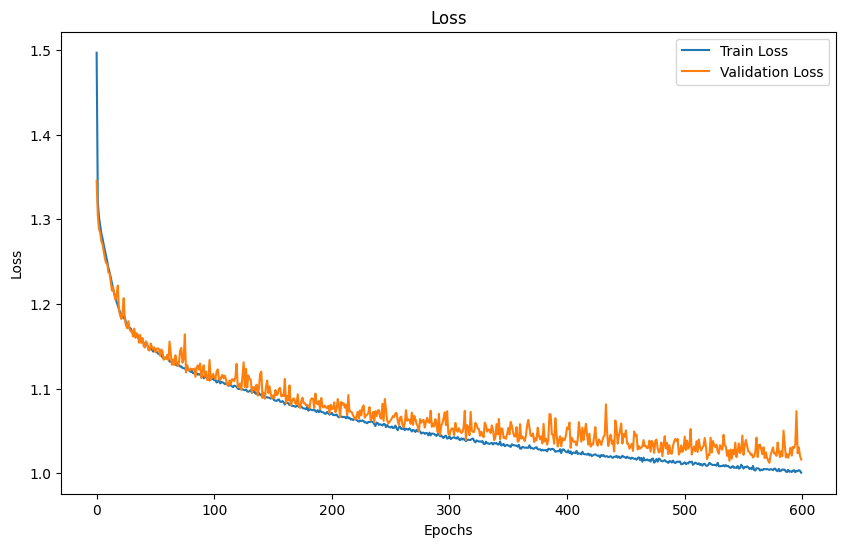

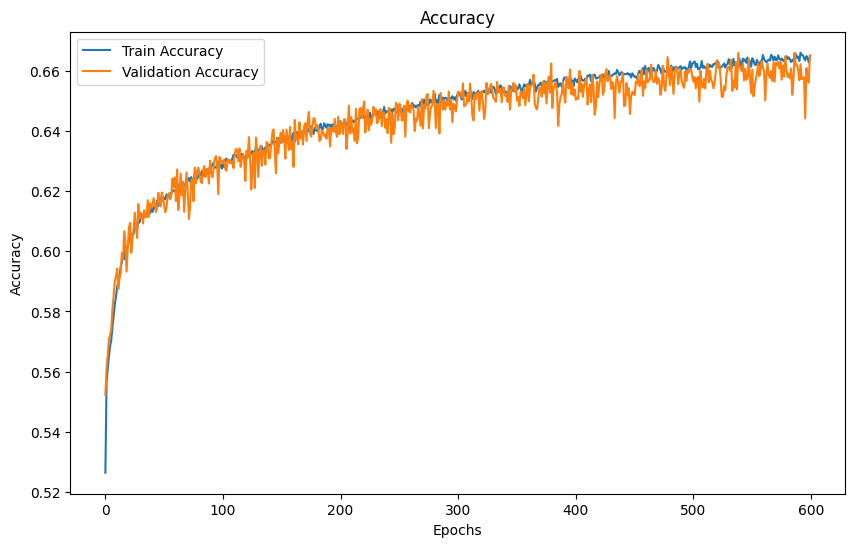

In [ ]:
# Graficar loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Graficar accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.show()

In [ ]:

# Crear el modelo
model_5 = Sequential()
model_5.add(Dense(1024, input_dim=input_dim_2, activation='relu'))
model_5.add(Dense(512, activation='relu'))
model_5.add(Dense(256, activation='relu'))
model_5.add(Dense(128, activation='relu'))
model_5.add(Dense(64, activation='relu'))
model_5.add(Dense(32, activation='relu'))
model_5.add(Dense(16, activation='softmax'))  # Última capa con activación softmax

# Compilar el modelo
model_5.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

epochs = 600
batch_size = 64

# Entrenar el modelo
history = model_5.fit(X_train_2, y_train_2, epochs=epochs, batch_size=batch_size, validation_data=(X_test_2, y_test_2), validation_split=0.2)

Epoch 1/600
733/733 [==============================] - 19s 25ms/step - loss: 0.1348 - accuracy: 0.5205 - val_loss: 0.1142 - val_accuracy: 0.5486
Epoch 2/600
733/733 [==============================] - 14s 20ms/step - loss: 0.1133 - accuracy: 0.5476 - val_loss: 0.1128 - val_accuracy: 0.5490
Epoch 3/600
733/733 [==============================] - 15s 20ms/step - loss: 0.1117 - accuracy: 0.5579 - val_loss: 0.1097 - val_accuracy: 0.5695
Epoch 4/600
733/733 [==============================] - 15s 20ms/step - loss: 0.1102 - accuracy: 0.5681 - val_loss: 0.1106 - val_accuracy: 0.5666
Epoch 5/600
733/733 [==============================] - 15s 20ms/step - loss: 0.1084 - accuracy: 0.5735 - val_loss: 0.1074 - val_accuracy: 0.5796
Epoch 6/600
733/733 [==============================] - 14s 19ms/step - loss: 0.1069 - accuracy: 0.5808 - val_loss: 0.1061 - val_accuracy: 0.5826
Epoch 7/600
733/733 [==============================] - 15s 20ms/step - loss: 0.1067 - accuracy: 0.5823 - val_loss: 0.1086 - val_ac

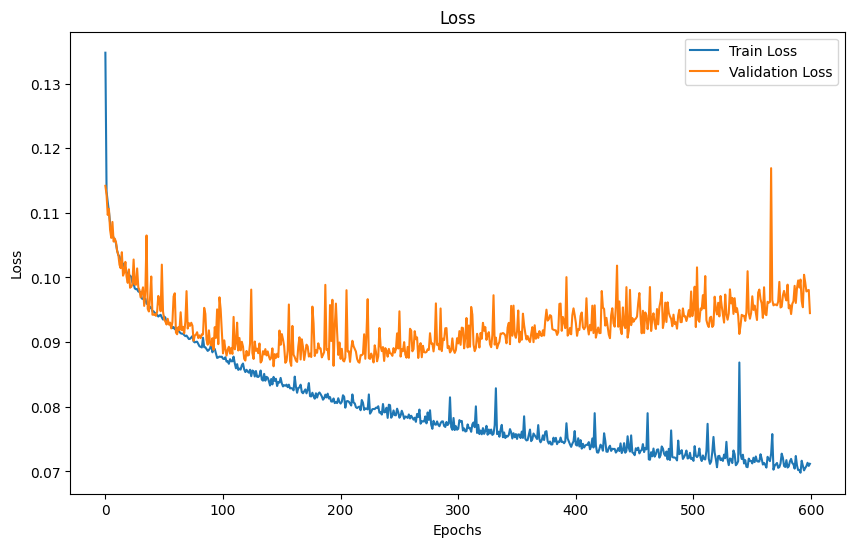

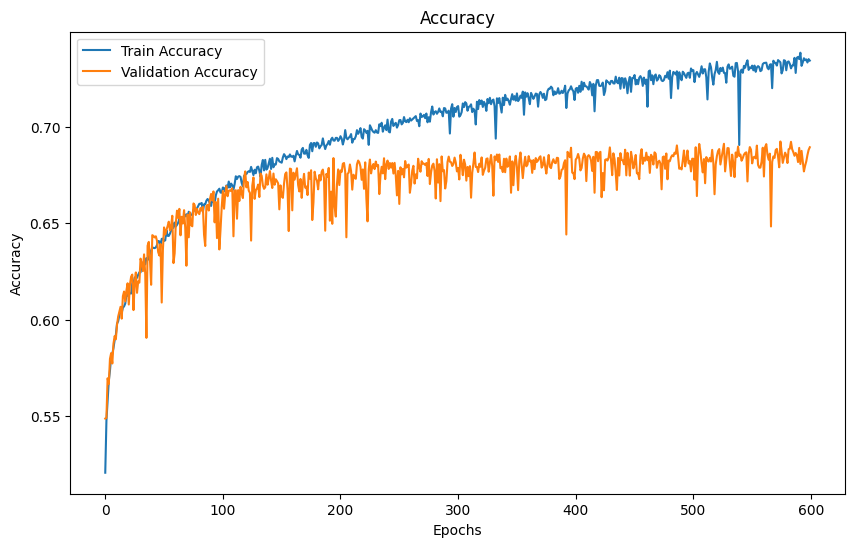

In [ ]:
# Graficar loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Graficar accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.show()

In [ ]:
from tensorflow.keras.layers import Dropout

# Obtener el número de clases
num_classes = y_train_2.shape[1]

# Crear el modelo
model_6 = Sequential()
model_6.add(Dense(128, input_dim=input_dim_2, activation='relu'))
model_6.add(Dropout(0.2))
model_6.add(Dense(64, activation='relu'))
model_6.add(Dropout(0.2))
model_6.add(Dense(32, activation='relu'))
model_6.add(Dropout(0.2))
model_6.add(Dense(num_classes, activation='softmax'))

# Compilar el modelo
model_6.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

epochs = 500  # Aumentar el número de épocas
batch_size = 64  # Ajustar el tamaño del lote

# Entrenar el modelo
history = model_6.fit(X_train_2, y_train_2, epochs=epochs, batch_size=batch_size, validation_data=(X_test_2, y_test_2))

Epoch 1/500
733/733 [==============================] - 3s 3ms/step - loss: 1.4955 - accuracy: 0.5229 - val_loss: 1.3542 - val_accuracy: 0.5412
Epoch 2/500
733/733 [==============================] - 2s 2ms/step - loss: 1.3385 - accuracy: 0.5495 - val_loss: 1.3024 - val_accuracy: 0.5525
Epoch 3/500
733/733 [==============================] - 2s 2ms/step - loss: 1.3162 - accuracy: 0.5555 - val_loss: 1.2904 - val_accuracy: 0.5610
Epoch 4/500
733/733 [==============================] - 2s 3ms/step - loss: 1.3039 - accuracy: 0.5608 - val_loss: 1.2785 - val_accuracy: 0.5637
Epoch 5/500
733/733 [==============================] - 2s 3ms/step - loss: 1.2924 - accuracy: 0.5663 - val_loss: 1.2660 - val_accuracy: 0.5741
Epoch 6/500
733/733 [==============================] - 2s 2ms/step - loss: 1.2855 - accuracy: 0.5683 - val_loss: 1.2594 - val_accuracy: 0.5806
Epoch 7/500
733/733 [==============================] - 2s 2ms/step - loss: 1.2738 - accuracy: 0.5733 - val_loss: 1.2465 - val_accuracy: 0.5853

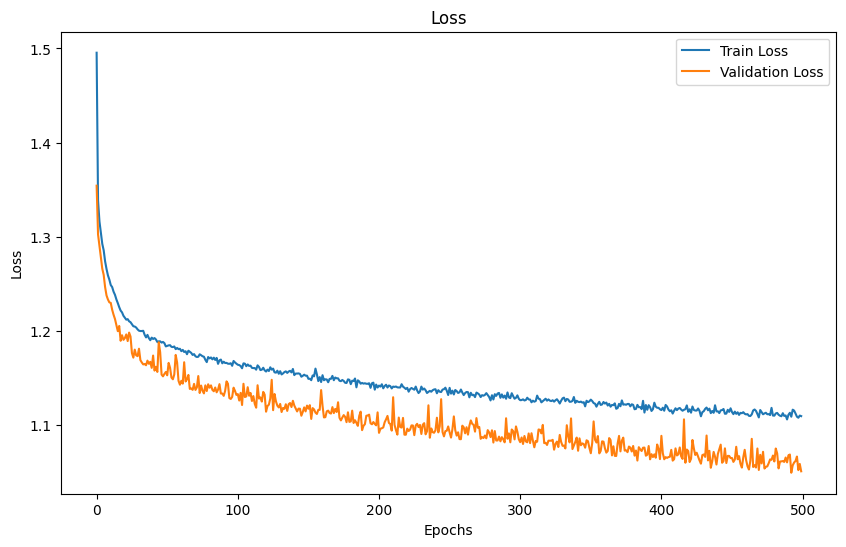

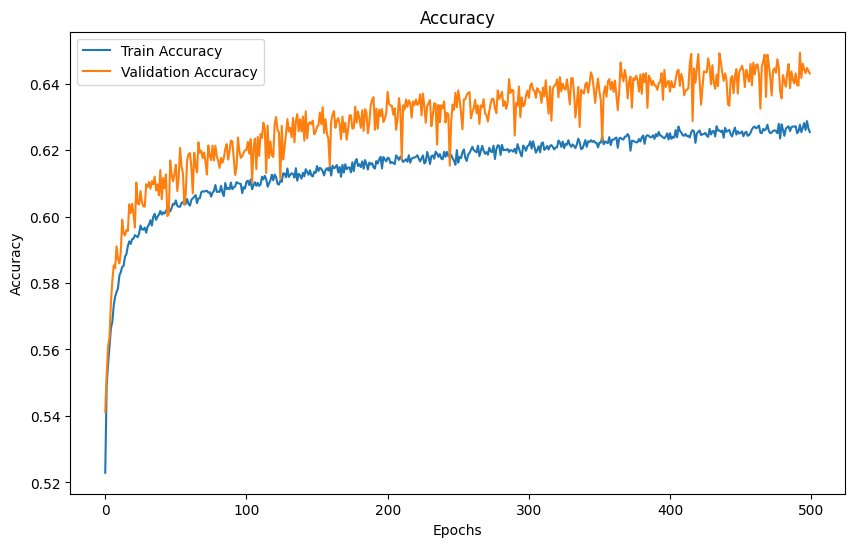

In [ ]:
# Graficar loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Graficar accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.show()

In [80]:
# Crear el modelo
model_7 = Sequential()
model_7.add(Dense(128, input_dim=input_dim_2, activation='relu'))
model_7.add(Dropout(0.2))
model_7.add(Dense(64, activation='relu'))
model_7.add(Dropout(0.2))
model_7.add(Dense(32, activation='relu'))
model_7.add(Dropout(0.2))
model_7.add(Dense(num_classes, activation='softmax'))

# Compilar el modelo
model_7.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

epochs = 500  # Aumentar el número de épocas
batch_size = 64  # Ajustar el tamaño del lote

# Entrenar el modelo
history = model_7.fit(X_train_2, y_train_2, epochs=epochs, batch_size=batch_size, validation_data=(X_test_2, y_test_2))

Epoch 1/500
733/733 [==============================] - 3s 3ms/step - loss: 0.1520 - accuracy: 0.4976 - val_loss: 0.1166 - val_accuracy: 0.5471
Epoch 2/500
733/733 [==============================] - 2s 3ms/step - loss: 0.1190 - accuracy: 0.5448 - val_loss: 0.1124 - val_accuracy: 0.5597
Epoch 3/500
733/733 [==============================] - 3s 4ms/step - loss: 0.1157 - accuracy: 0.5513 - val_loss: 0.1112 - val_accuracy: 0.5586
Epoch 4/500
733/733 [==============================] - 2s 3ms/step - loss: 0.1143 - accuracy: 0.5569 - val_loss: 0.1109 - val_accuracy: 0.5611
Epoch 5/500
733/733 [==============================] - 2s 3ms/step - loss: 0.1135 - accuracy: 0.5591 - val_loss: 0.1104 - val_accuracy: 0.5590
Epoch 6/500
733/733 [==============================] - 2s 3ms/step - loss: 0.1129 - accuracy: 0.5629 - val_loss: 0.1096 - val_accuracy: 0.5668
Epoch 7/500
733/733 [==============================] - 2s 2ms/step - loss: 0.1122 - accuracy: 0.5642 - val_loss: 0.1090 - val_accuracy: 0.5695

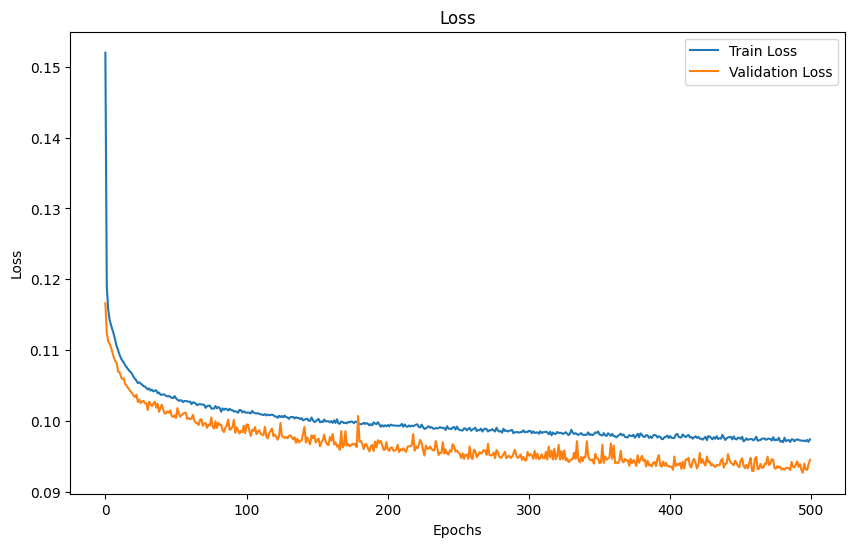

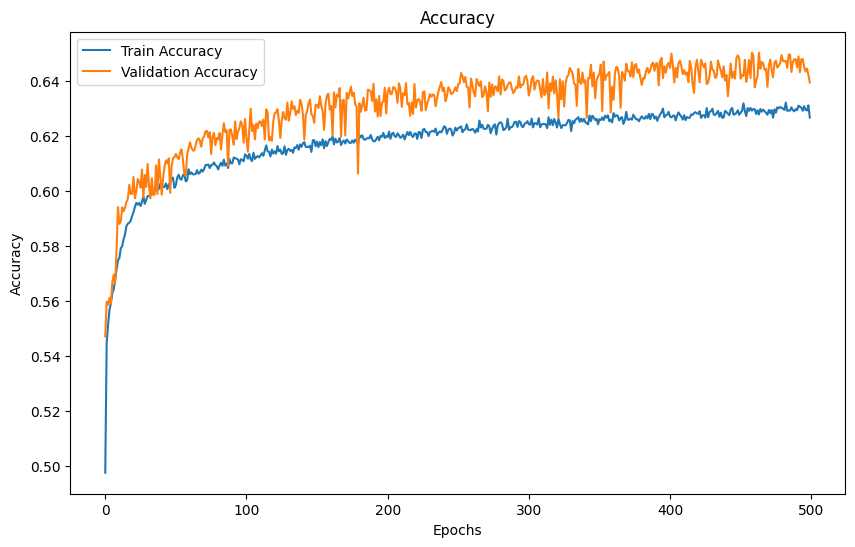

In [81]:
# Graficar loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Graficar accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.show()

In [82]:
# Crear el modelo
model_8 = Sequential()
model_8.add(Dense(1024, input_dim=input_dim_2, activation='relu'))
model_8.add(Dense(512, activation='relu'))
model_8.add(Dense(256, activation='relu'))
model_8.add(Dense(128, activation='relu'))
model_8.add(Dense(64, activation='relu'))
model_8.add(Dense(32, activation='relu'))
model_8.add(Dense(16, activation='softmax'))  # Última capa con activación softmax

# Compilar el modelo
model_8.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

epochs = 600
batch_size = 64

# Entrenar el modelo
history = model_8.fit(X_train_2, y_train_2, epochs=epochs, batch_size=batch_size, validation_data=(X_test_2, y_test_2), validation_split=0.2)

Epoch 1/600
733/733 [==============================] - 13s 16ms/step - loss: 1.3952 - accuracy: 0.5381 - val_loss: 1.3010 - val_accuracy: 0.5520
Epoch 2/600
733/733 [==============================] - 11s 15ms/step - loss: 1.3071 - accuracy: 0.5546 - val_loss: 1.2907 - val_accuracy: 0.5621
Epoch 3/600
733/733 [==============================] - 12s 16ms/step - loss: 1.2901 - accuracy: 0.5631 - val_loss: 1.2721 - val_accuracy: 0.5646
Epoch 4/600
733/733 [==============================] - 11s 15ms/step - loss: 1.2676 - accuracy: 0.5713 - val_loss: 1.2775 - val_accuracy: 0.5624
Epoch 5/600
733/733 [==============================] - 11s 15ms/step - loss: 1.2541 - accuracy: 0.5775 - val_loss: 1.2325 - val_accuracy: 0.5905
Epoch 6/600
733/733 [==============================] - 11s 16ms/step - loss: 1.2392 - accuracy: 0.5846 - val_loss: 1.2102 - val_accuracy: 0.5957
Epoch 7/600
733/733 [==============================] - 12s 16ms/step - loss: 1.2213 - accuracy: 0.5904 - val_loss: 1.2076 - val_ac

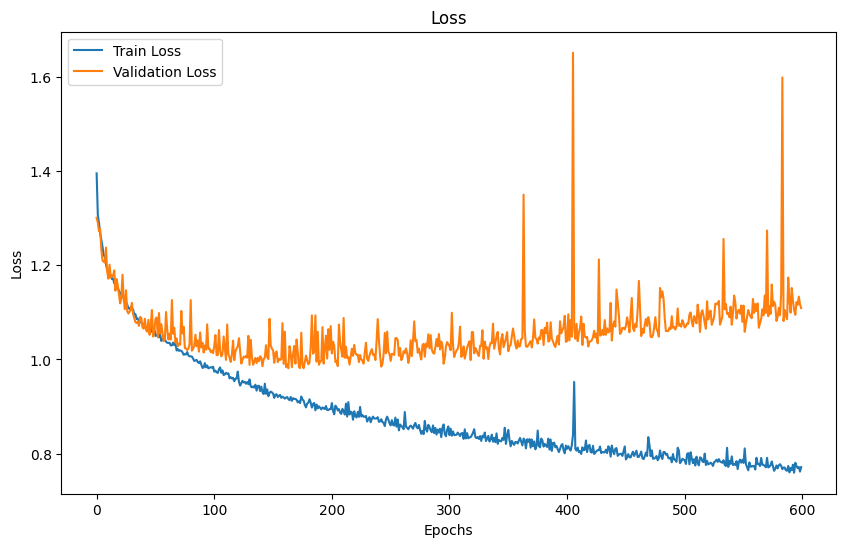

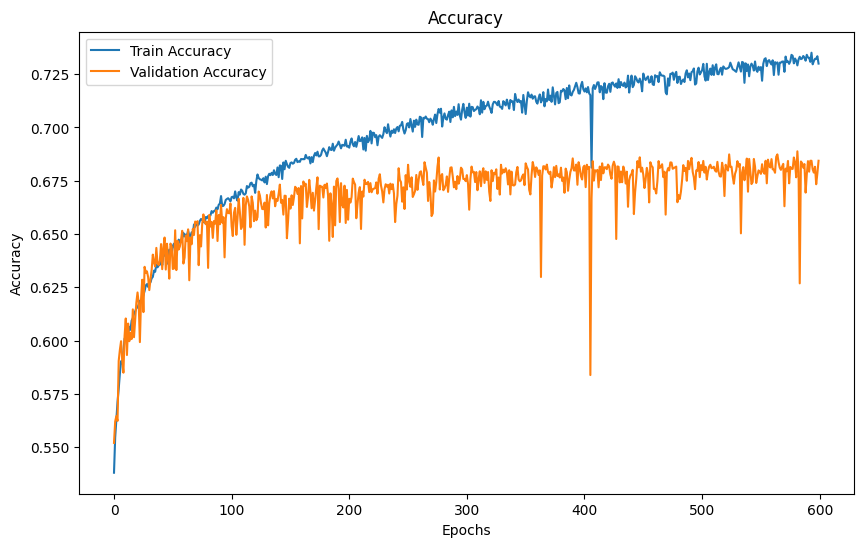

In [83]:
# Graficar loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Graficar accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.show()

In [31]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# Crear el modelo
model_9 = Sequential()
model_9.add(Dense(1024, input_dim=input_dim_2, activation='relu'))
model_9.add(BatchNormalization())  # Normalización por lotes
model_9.add(Dropout(0.2))  # Dropout con una tasa de 0.2

model_9.add(Dense(512, activation='relu'))
model_9.add(BatchNormalization())
model_9.add(Dropout(0.2))

model_9.add(Dense(256, activation='relu'))
model_9.add(BatchNormalization())
model_9.add(Dropout(0.2))

model_9.add(Dense(128, activation='relu'))
model_9.add(BatchNormalization())
model_9.add(Dropout(0.2))

model_9.add(Dense(64, activation='relu'))
model_9.add(BatchNormalization())
model_9.add(Dropout(0.2))

model_9.add(Dense(32, activation='relu'))
model_9.add(BatchNormalization())
model_9.add(Dropout(0.2))

model_9.add(Dense(16, activation='softmax'))  # Última capa con activación softmax

# Compilar el modelo
model_9.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

epochs = 600
batch_size = 64

# Entrenar el modelo
history = model_9.fit(X_train_2, y_train_2, epochs=epochs, batch_size=batch_size, validation_data=(X_test_2, y_test_2), validation_split=0.2)

Epoch 1/600
733/733 [==============================] - 20s 23ms/step - loss: 1.4116 - accuracy: 0.5484 - val_loss: 1.2784 - val_accuracy: 0.5733
Epoch 2/600
733/733 [==============================] - 17s 23ms/step - loss: 1.2784 - accuracy: 0.5792 - val_loss: 1.8290 - val_accuracy: 0.4439
Epoch 3/600
733/733 [==============================] - 18s 25ms/step - loss: 1.2412 - accuracy: 0.5912 - val_loss: 2.0170 - val_accuracy: 0.5397
Epoch 4/600
733/733 [==============================] - 16s 22ms/step - loss: 1.2207 - accuracy: 0.5945 - val_loss: 5.8172 - val_accuracy: 0.0717
Epoch 5/600
733/733 [==============================] - 16s 22ms/step - loss: 1.2080 - accuracy: 0.5995 - val_loss: 1.5326 - val_accuracy: 0.5623
Epoch 6/600
733/733 [==============================] - 17s 23ms/step - loss: 1.2030 - accuracy: 0.5994 - val_loss: 3.0987 - val_accuracy: 0.4241
Epoch 7/600
733/733 [==============================] - 17s 23ms/step - loss: 1.1945 - accuracy: 0.6029 - val_loss: 1.4510 - val_ac

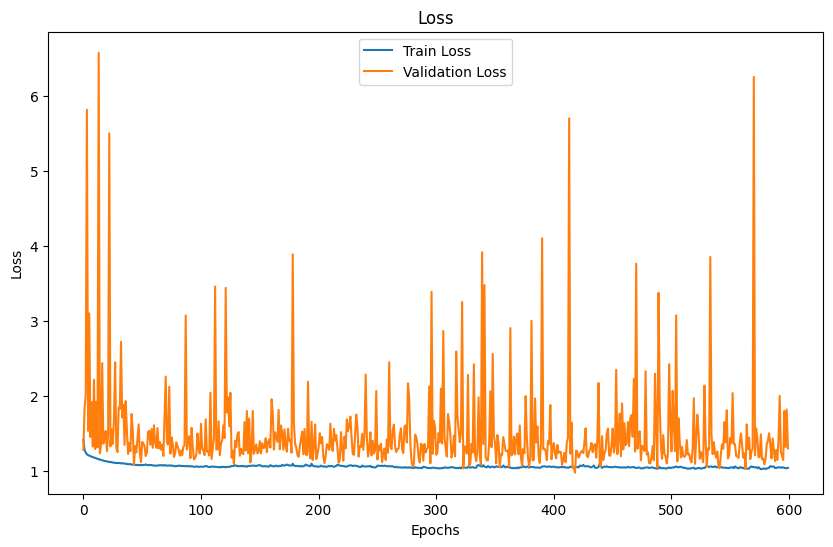

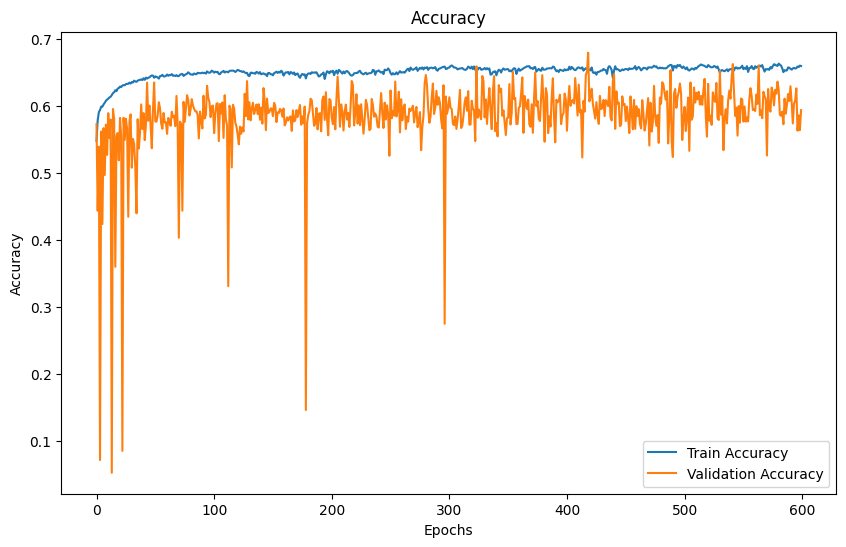

In [32]:
# Graficar loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Graficar accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.show()

In [ ]:
# Crear el modelo
model_10 = Sequential()
model_10.add(Dense(1024, input_dim=input_dim_2, activation='relu'))
model_10.add(BatchNormalization())  # Normalización por lotes
model_10.add(Dropout(0.2))  # Dropout con una tasa de 0.2

model_10.add(Dense(512, activation='relu'))
model_10.add(BatchNormalization())
model_10.add(Dropout(0.2))

model_10.add(Dense(256, activation='relu'))
model_10.add(BatchNormalization())
model_10.add(Dropout(0.2))

model_10.add(Dense(128, activation='relu'))
model_10.add(BatchNormalization())
model_10.add(Dropout(0.2))

model_10.add(Dense(64, activation='relu'))
model_10.add(BatchNormalization())
model_10.add(Dropout(0.2))

model_10.add(Dense(32, activation='relu'))
model_10.add(BatchNormalization())
model_10.add(Dropout(0.2))

model_10.add(Dense(16, activation='softmax'))  # Última capa con activación softmax

# Compilar el modelo
model_10.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

epochs = 600
batch_size = 64

# Entrenar el modelo
history = model_10.fit(X_train_2, y_train_2, epochs=epochs, batch_size=batch_size, validation_data=(X_test_2, y_test_2), validation_split=0.2)